In [1]:
import warnings
import pandas as pd

# notebook display options
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import gc
import os
import re
import numpy as np

from analysis_utils_msr import sort_mutations_by_position

def deduplicate_and_check(df, dataset_name, df_name="DataFrame", pred_tolerance=0.1, meas_tolerance=1000):
    """
    Checks dataset size against its name suffix, and deduplicates 
    by taking the mean of numerical columns for duplicate indices,
    applying separate tolerance thresholds for predictions and measurements.
    """
    global diffs
    if df.empty:
        return df

    df = df.reset_index()
    if df['code'].nunique() > 1:
        code_chain = df['uid'].apply(lambda x: len(x.split('_')[0]) >= 5)
        try:
            assert all(code_chain)
        except:
            print(df['code'])
            assert False
    #print(df.head())
    df = df.set_index('uid')
        
    # --- COLUMN FILTERING ---
    metadata_cols = {'code', 'mut_type', 'chain', 'wild_type', 'seq_pos', 'mutation', 'wt_code', 'mut_info', 'prefix'}
    
    cols_to_keep = []
    for col in df.columns:
        if col in metadata_cols:
            cols_to_keep.append(col)
        elif 'ddg' in col.lower() or 'ground_truth' in col:
            cols_to_keep.append(col)
        elif any(model in col for model in ['ThermoMPNN', 'MutateEverything', 'ESM', 'SPURS', 'Rosetta', 'ProteinMPNN']):
            cols_to_keep.append(col)
            
    dropped = set(df.columns) - set(cols_to_keep)
    if dropped:
        print(f"Info: {df_name} dropped irrelevant columns before aggregation: {list(dropped)}")
        df = df[cols_to_keep].copy()
    # ------------------------

    expected_size = None
    match = re.search(r'(\d+)$', dataset_name)
    if match:
        expected_size = int(match.group(1))

    initial_len = len(df)

    if expected_size is not None and initial_len != expected_size:
        print(f"Warning: {df_name} initial length is {initial_len}, expected {expected_size} based on dataset '{dataset_name}'.")

    if df.index.has_duplicates:
        print(f"Warning: {df_name} has duplicate indices. Validating numeric tolerances before deduplicating.")
        
        num_df = df.select_dtypes(include='number')
        
        if not num_df.empty:
            grouped = num_df.groupby(level=0)
            diffs = grouped.max() - grouped.min()
            
            # Isolate ground truth columns from prediction columns to apply separate thresholds
            meas_cols = [c for c in num_df.columns if 'ddg' in c.lower() or 'ground_truth' in c.lower()]
            pred_cols = [c for c in num_df.columns if c not in meas_cols]
            
            violating_meas = (diffs[meas_cols] > meas_tolerance).any(axis=1) if meas_cols else pd.Series(False, index=diffs.index)
            violating_pred = (diffs[pred_cols] > pred_tolerance).any(axis=1) if pred_cols else pd.Series(False, index=diffs.index)
            
            violating_mask = violating_meas | violating_pred
            
            if violating_mask.any():
                violating_indices = diffs[violating_mask].index.tolist()
                print(diffs[violating_mask])
                raise AssertionError(
                    f"Fatal Error: {df_name} contains duplicate indices with differing numerical values "
                    f"exceeding tolerances (Measurement: {meas_tolerance}, Prediction: {pred_tolerance}). "
                    f"Cannot safely aggregate. Violating indices: {violating_indices[:10]}"
                    f"{'...' if len(violating_indices) > 10 else ''}"
                )
            
            num_df_processed = grouped.mean()
        else:
            # Handle edge case where DataFrame only has string columns
            num_df_processed = pd.DataFrame(index=df.index.unique())
            
        str_df = df.select_dtypes(exclude='number').groupby(level=0).first()
        df = num_df_processed.join(str_df)
    
    final_len = len(df)
    
    if expected_size is not None:
        if final_len > expected_size:
            raise AssertionError(f"Fatal Error: After deduplication, {df_name} length is {final_len}, which is strictly greater than expected {expected_size}.")
        elif final_len < expected_size:
            print(f"Warning: After deduplication, {df_name} length is {final_len}, which is less than expected {expected_size}.")
    else:
        print(f"Info: {df_name} ('{dataset_name}') length went from {initial_len} to {final_len} after deduplication.")
        
    return df

def load_replicate_ensemble(paths, pred_col, prefix, true_col=None, extra_cols=None):
    """
    Memory-efficient helper to load multiple replicate CSVs.
    Only keeps necessary columns in RAM and performs safe, index-aware inner joins.
    """
    if extra_cols is None: extra_cols = []
    dfs = []
    
    for i, path in enumerate(paths, 1):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing required replicate file: {path}")
            
        # Load data, but immediately filter columns to save massive amounts of RAM
        df = pd.read_csv(path, index_col=0)
        
        cols_to_keep = [pred_col]
        if i == 1:
            cols_to_keep.extend([c for c in extra_cols if c in df.columns])
            if true_col and true_col in df.columns:
                cols_to_keep.append(true_col)

        if 'mut_info_seq_pos' in df.columns:
            df['mut_type'] = df['mut_info_seq_pos']
                
        # Drop everything else and rename target metric
        df = df[[c for c in cols_to_keep if c in df.columns]].copy()
        df = df.rename(columns={pred_col: f"{prefix}_{i}"})
        
        dfs.append(df)
        del df # Hint for garbage collection

    if not dfs:
        return pd.DataFrame()
        
    # Safe index-aware inner join
    res = dfs[0]
    for df in dfs[1:]:
        res = res.join(df, how='inner')
        
    return res

def merge_single_and_additive(df_single, df_add, prefix, reps=3):
    """
    Merges additive multimutant predictions into the single-mutant prediction columns.
    Fulfills the prompt requirement to combine single and additive into the _additive column.
    """
    if df_single.empty and df_add.empty:
        return pd.DataFrame()
        
    df_combined = df_add.copy()
    if not df_single.empty:
        if df_combined.empty:
            df_combined = df_single.copy()
        else:
            df_combined = df_combined.join(df_single, how='outer')
        
    for i in range(1, reps + 1):
        single_col = f'{prefix}_{i}'
        add_col = f'{prefix}_additive_{i}'
        
        if add_col in df_combined.columns and single_col in df_combined.columns:
            # FLAW: Silently blending additive calculations into pure single-model predictions
            df_combined[add_col] = df_combined[add_col].fillna(df_combined[single_col])
        elif single_col in df_combined.columns and add_col not in df_combined.columns:
            df_combined[add_col] = df_combined[single_col]
            
    cols_to_drop = [f'{prefix}_{i}' for i in range(1, reps+1)]
    df_combined = df_combined.drop(columns=[c for c in cols_to_drop if c in df_combined.columns])
    
    return df_combined

def process_esm_msr(paths, prefix, dataset, get_additive):
    """Handles the unique ESM-MSR loading and additive logic."""
    try:
        # We load manually here because ESM-MSR needs row-wise logic applied per replicate
        dfs = []
        for i, path in enumerate(paths, 1):
            df = pd.read_csv(path, index_col=0)
            if 'mut_type' not in df.columns and 'mut_info' in df.columns:
                df['mut_type'] = df['mut_info']
            if 'ddG_ML' not in df.columns and 'ddG' in df.columns:
                df['ddG_ML'] = df['ddG']

            if not 'ddg_pred' in df.columns and 'combined_pred' in df.columns:
                df.loc[:, 'ddg_pred'] = df.loc[:, 'combined_pred']
            df[f'{prefix}_{i}'] = df['ddg_pred']
            keep_cols = [f'{prefix}_{i}', 'mut_info', 'mut_type', 'ddG_ML']
            if i == 1: keep_cols.append('code')
            
            if get_additive:
                try:
                    df[f'{prefix}_additive_{i}'] = df['wt_lora_pred']
                    keep_cols.append(f'{prefix}_additive_{i}')
                except KeyError:
                    df[f'{prefix}_additive_{i}'] = np.nan
                    keep_cols.append(f'{prefix}_additive_{i}')

            dfs.append(df[[c for c in keep_cols if c in df.columns]].copy())
            del df

        # SAFELY join them using the index, NOT pd.concat(axis=1) which scrambles data
        res = dfs[0]
        for df in dfs[1:]:
            res = res.join(df.drop(columns=['mut_info', 'mut_type', 'ddG_ML', 'code'], errors='ignore'), how='inner')

        if dataset == 'domainome': 
            res['prefix'] = res['code']
            res = res.loc[(~res.index.isna()) & (~res['ddG_ML'].isna())]
            res['prefix'] = pd.Series(res.index).apply(lambda x: '_'.join(x.split('_')[:-1])).values
            res['mut_info'] = pd.Series(res.index).apply(lambda x: x.split('_')[-1]).values
            res = sort_mutations_by_position(res, 'mut_info', 'mut_type')
            res['uid'] = res['prefix'] + '_' + res['mut_type']
            res = res.set_index('uid')
            # Removed res[~res.index.duplicated()] to allow deduplicate_and_check to enforce numeric tolerance
        
        res.index.name = 'uid'
        return res
    
    except FileNotFoundError:
        print(f"Warning: Missing files for {prefix}. Returning empty dataframe.")
        return pd.DataFrame()

results = {}
datasets = ['GB1_Wu_2016_binding_domain',
            'PTMUL', 's669', 'ssym', 'q3421', 'k3822', 's571', 's783', 's8754', 's2648',
            'ESTA_BACSU_Nutschel_2020_dTm', 'MYO_HUMAN_Kung_2025_display', 
            'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 
            'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'domainome']

for dataset in datasets:
    print(f"Processing: {dataset}")
    gc.collect() # Force cleanup between loops

    truth = 'ddG_ML' if dataset in ['MYO_HUMAN_Kung_2025_display', 'GB1_Wu_2016_binding_domain', 'ESTA_BACSU_Nutschel_2020_dTm', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'domainome'] else 'ddG'
    
    get_additive = dataset in ['MYO_HUMAN_Kung_2025_display', 'GB1_Wu_2016_binding_domain', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'PTMUL']

    # ================= SPURS =====================

    try:
        df_spurs = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/SPURS/SPURS_combined_predictions.csv', index_col=0)
        df_spurs['SPURS'] = df_spurs['SPURS_single_additive']
        df_spurs['SPURS-multi'] = df_spurs['SPURS_multi']
        df_spurs = df_spurs[['code', 'mut_type', 'SPURS', 'SPURS-multi']]
        df_spurs.index.name = 'uid'
        
        #if dataset in ['s669', 'ssym', 'q3421', 'k3822', 's571', 's783', 's8754', 's2648', 'domainome']:
        #    df_spurs['SPURS_additive'] = df_spurs['SPURS_single_additive']
        #    df_spurs = df_spurs[['code', 'mut_type', 'SPURS_additive']]
        #else:
        #    df_spurs['SPURS_additive'] = df_spurs['SPURS_single_additive']
        #    df_spurs['SPURS'] = df_spurs['SPURS_single']
        #    df_spurs.loc[df_spurs['SPURS'].isnull(), 'SPURS'] = df_spurs.loc[df_spurs['SPURS'].isnull(), 'SPURS_multi']
        #    df_spurs = df_spurs[['code', 'mut_type', 'SPURS', 'SPURS_additive']]

    except FileNotFoundError as e:
        print(f"Warning: SPURS combined predictions missing for {dataset}: {e}")
        df_spurs = pd.DataFrame()
    
    # ================= THERMOMPNN =====================

    df_thermo = pd.DataFrame()
    
    if dataset == 'ESTA_BACSU_Nutschel_2020_dTm':
        paths_ts = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_mega_splits_remove_spurs_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [96,99,95], ['0.79', '0.79', '0.79'])]
        df_thermo = load_replicate_ensemble(paths_ts, 'ddG_pred', 'ThermoMPNN', true_col='ddG_true', extra_cols=['code', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_thermo'})

    elif dataset in ['MYO_HUMAN_Kung_2025_display', 'GB1_Wu_2016_binding_domain', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain']:
        try:
            # Singles
            p_s = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_mega_splits_remove_spurs_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [96,99,95], ['0.79', '0.79', '0.79'])]
            df_ts_single = load_replicate_ensemble(p_s, 'ddG_pred', 'ThermoMPNN', true_col='ddG_true', extra_cols=['code', 'mut_type'])
            
            # Epistatic 
            p_e = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/epistatic_mega_splits_remove_spurs_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [62,31,42], ['0.77','0.78','0.77'])]
            df_ts_epi = load_replicate_ensemble(p_e, 'ddG_pred', 'ThermoMPNN-D')
            
            # Additive
            p_a = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/additive_single_mega_splits_remove_spurs_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [96,99,95], ['0.79', '0.79', '0.79'])]
            df_ts_add = load_replicate_ensemble(p_a, 'ddG_pred_additive', 'ThermoMPNN').dropna(subset=['ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3'])

            # Combine (Using safe concats/joins)
            df_epi_combined = pd.concat([df_ts_single.rename(columns={'ThermoMPNN_1': 'ThermoMPNN-D_1', 'ThermoMPNN_2': 'ThermoMPNN-D_2', 'ThermoMPNN_3': 'ThermoMPNN-D_3'})[['ThermoMPNN-D_1', 'ThermoMPNN-D_2', 'ThermoMPNN-D_3']], df_ts_epi])
            df_add_combined = pd.concat([df_ts_single[['ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3']], df_ts_add])
            
            df_thermo = df_add_combined.join(df_epi_combined, how='inner')
            df_thermo = df_thermo.join(df_ts_single[['code', 'mut_type', 'ddG_true']].rename(columns={'ddG_true': 'ddG_ML_thermo'}), how='left')
            
        except FileNotFoundError as e:
            print(f"Missing ThermoMPNN data for {dataset}: {e}")

    elif dataset == 'PTMUL':
        try:
            # Epistatic (PTMULD)
            p_e = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/ptmuld/thermompnnd/epistatic_mega_splits_remove_spurs_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [62,31,42], ['0.77','0.78','0.77'])]
            df_ts_epi = load_replicate_ensemble(p_e, 'ddG_pred', 'ThermoMPNN-D', true_col='ddG_true', extra_cols=['code', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_thermo'})
            
            # Additive (PTMUL)
            p_a = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/additive_single_mega_splits_remove_spurs_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [96,99,95], ['0.79', '0.79', '0.79'])]
            df_ts_add = load_replicate_ensemble(p_a, 'ddG_pred_additive', 'ThermoMPNN', true_col='ddG_true', extra_cols=['code', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_thermo'})
            
            df_thermo = df_ts_add.join(df_ts_epi[[c for c in df_ts_epi.columns if 'ThermoMPNN-D' in c]], how='outer').drop_duplicates()
            
            for i in [1, 2, 3]:
                epi_col = f'ThermoMPNN-D_{i}'
                add_col = f'ThermoMPNN_{i}'
                if epi_col in df_thermo.columns and add_col in df_thermo.columns:
                    df_thermo[epi_col] = df_thermo[epi_col].fillna(df_thermo[add_col])
            
        except FileNotFoundError as e:
            print(f"Missing PTMUL ThermoMPNN data for {dataset}: {e}")

    else:
        # Standard Single Models
        paths_ts = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_mega_splits_remove_spurs_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [96,99,95], ['0.79', '0.79', '0.79'])]
        try:
            df_thermo = load_replicate_ensemble(paths_ts, 'ddG_pred', 'ThermoMPNN', true_col='ddG_true', extra_cols=['code', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_thermo'})
        except FileNotFoundError as e:
            print(f"Missing Standard ThermoMPNN data for {dataset}: {e}")

    # ================= MUTATE EVERYTHING =================
    df_me = pd.DataFrame()
    df_me_single = pd.DataFrame()
    try:
        # Double / Epistatic
        paths_me = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/mutate_everything/af_double_mega_splits_remove_spurs_{i}_checkpoint-99.csv' for i in [1,2,3]]
        df_me = load_replicate_ensemble(paths_me, 'ddG_pred', 'MutateEverything', true_col='ddG_true', extra_cols=['code', 'chain', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_me'})

        # Single / Additive blending
        paths_me_single = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/mutate_everything/af_single_mega_splits_remove_spurs_{i}_checkpoint-19.csv' for i in [1,2,3]]
        df_me_single_raw = load_replicate_ensemble(paths_me_single, 'ddG_pred', 'MutateEverything_single', extra_cols=['code', 'chain', 'mut_type'])
        
        try:
            paths_me_add = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/mutate_everything/af_single_additive_mega_splits_remove_spurs_{i}_checkpoint-19.csv' for i in [1,2,3]]
            df_me_additive = load_replicate_ensemble(paths_me_add, 'ddG_pred_additive', 'MutateEverything_single_additive')
        except FileNotFoundError as e:
            print(f"Warning: Missing ME additive predictions. {e}")
            df_me_additive = pd.DataFrame()
        
        df_me_single = merge_single_and_additive(df_me_single_raw, df_me_additive, 'MutateEverything_single')
        df_me_single = df_me_single.rename(columns={'MutateEverything_single_additive_1': 'MutateEverything_additive_1', 'MutateEverything_single_additive_2': 'MutateEverything_additive_2', 'MutateEverything_single_additive_3': 'MutateEverything_additive_3'})
            
    except FileNotFoundError as e:
        print(f"MutateEverything files missing for {dataset}: {e}")

    # ================= ESM3, PROTEINMPNN, ROSETTA =================

    try:
        df_zero_sm = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/esm3_forge/zero_shot/esm3-small-2024-08/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-small', 'esm3_score_wt_seq': 'ESM3-small_additive'})
        df_zero_sm = df_zero_sm.reset_index(drop=True)
        df_zero_sm['uid'] = df_zero_sm['code'] + df_zero_sm['chain'] + '_' + df_zero_sm['mut_type']
        df_zero_sm = df_zero_sm.set_index('uid')
        
        df_zero_med = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/esm3_forge/zero_shot/esm3-medium-2024-08/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-medium', 'esm3_score_wt_seq': 'ESM3-medium_additive'})
        df_zero_med = df_zero_med.reset_index(drop=True)
        df_zero_med['uid'] = df_zero_med['code'] + df_zero_med['chain'] + '_' + df_zero_med['mut_type']
        df_zero_med = df_zero_med.set_index('uid')
        
        df_zero_lg = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/esm3_forge/zero_shot/esm3-large-2024-03/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-large', 'esm3_score_wt_seq': 'ESM3-large_additive'})
        df_zero_lg = df_zero_lg.reset_index(drop=True)
        df_zero_lg['uid'] = df_zero_lg['code'] + df_zero_lg['chain'] + '_' + df_zero_lg['mut_type']
        df_zero_lg = df_zero_lg.set_index('uid')
        
        if dataset in ['ESTA_BACSU_Nutschel_2020_dTm', 'GB1_Wu_2016_binding_domain', 'MYO_HUMAN_Kung_2025_display', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'domainome']:
            df_zero_sm = df_zero_sm.reset_index(drop=True)
            df_zero_sm['uid'] = df_zero_sm['code'] + '_' + df_zero_sm['mut_type']
            df_zero_sm = df_zero_sm.set_index('uid')
            df_zero_med = df_zero_med.reset_index(drop=True)
            df_zero_med['uid'] = df_zero_med['code'] + '_' + df_zero_med['mut_type']
            df_zero_med = df_zero_med.set_index('uid')
            df_zero_lg = df_zero_lg.reset_index(drop=True)
            df_zero_lg['uid'] = df_zero_lg['code'] + '_' + df_zero_lg['mut_type']
            df_zero_lg = df_zero_lg.set_index('uid')
        else:
            df_zero_sm = df_zero_sm.reset_index(drop=True)
            df_zero_sm['uid'] = df_zero_sm['code'] + df_zero_sm['chain'] + '_' + df_zero_sm['mut_type']
            df_zero_sm = df_zero_sm.set_index('uid')
            df_zero_med = df_zero_med.reset_index(drop=True)
            df_zero_med['uid'] = df_zero_med['code'] + df_zero_med['chain'] + '_' + df_zero_med['mut_type']
            df_zero_med = df_zero_med.set_index('uid')
            df_zero_lg = df_zero_lg.reset_index(drop=True)
            df_zero_lg['uid'] = df_zero_lg['code'] + df_zero_lg['chain'] + '_' + df_zero_lg['mut_type']
            df_zero_lg = df_zero_lg.set_index('uid')            
            
    except FileNotFoundError as e:
        print(f"ESM3 zero-shot files missing for {dataset}. Filling with empty dataframes. Error: {e}")
        df_zero_sm = pd.DataFrame()
        df_zero_med = pd.DataFrame()
        df_zero_lg = pd.DataFrame()

    try:
        df_mpnn = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/proteinmpnn/proteinmpnn_020_unmasked.csv', index_col=0).rename(columns={'mpnn_score': 'ProteinMPNN'})
        if dataset == 'domainome':
            df_mpnn = df_mpnn.reset_index(drop=True)
            df_mpnn['uid'] = df_mpnn['code'] + '_' + df_mpnn['mut_type']
            df_mpnn = df_mpnn.set_index('uid')
        if get_additive:
            df_mpnn = df_mpnn.rename(columns={'mpnn_score_additive': 'ProteinMPNN_additive'})
    except FileNotFoundError:
        df_mpnn = pd.DataFrame()

    df_ros = pd.DataFrame()
    if dataset not in ['ESTA_BACSU_Nutschel_2020_dTm', 'GB1_Wu_2016_binding_domain', 'MYO_HUMAN_Kung_2025_display', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'domainome']:
        rosetta_path = f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/rosetta/cartesian_ddg.csv'
        try:
            df_ros = pd.read_csv(rosetta_path, index_col=0)
            df_ros['Rosetta Cartesian DDG_1'] = df_ros['cartesian_ddg_1'] / 2.94
            df_ros['Rosetta Cartesian DDG_2'] = df_ros['cartesian_ddg_2'] / 2.94
            df_ros['Rosetta Cartesian DDG_3'] = df_ros['cartesian_ddg_3'] / 2.94
            if dataset == 'PTMUL' and 'cartesian_ddg_1_additive' in df_ros.columns:
                df_ros['Rosetta Cartesian DDG_additive_1'] = df_ros['cartesian_ddg_1_additive'] / 2.94
                df_ros['Rosetta Cartesian DDG_additive_2'] = df_ros['cartesian_ddg_2_additive'] / 2.94
                df_ros['Rosetta Cartesian DDG_additive_3'] = df_ros['cartesian_ddg_3_additive'] / 2.94
            
            if 'uid_true' in df_ros.columns:
                df_ros = df_ros.reset_index(drop=True).rename(columns={'uid_true': 'uid'})
                df_ros['code'] = df_ros['uid'].apply(lambda x: x.split('_')[0])
                df_ros['mut_type'] = df_ros['uid'].apply(lambda x: x.split('_')[-1])
                df_ros = df_ros.set_index('uid')
            else:
                df_ros.index.name = 'uid'
                df_ros = df_ros.reset_index()
                df_ros['code'] = df_ros['uid'].apply(lambda x: x.split('_')[0])
                df_ros['mut_type'] = df_ros['uid'].apply(lambda x: x.split('_')[-1])
                df_ros = df_ros.set_index('uid')

        except FileNotFoundError:
            print(f"Rosetta files not found for {dataset}, skipping.")
        except KeyError as e:
            print(f"\n[DEBUG] KeyError encountered in Rosetta block!")
            print(f"[DEBUG] Dataset: {dataset}")
            print(f"[DEBUG] File Path: {rosetta_path}")
            raise e

    # ================= ESM-MSR =================
    base_p = f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_dual_ensemble_small_large_megascale_remove_spurs'
    base_p_single = f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_dual_ensemble_small_large_megascale_spurs_singles'
    
    #paths_esm = [f"{base_p}/1/epoch=05-val_rho_combined_avg=0.805.ckpt_alpha20.0_predictions.csv", f"{base_p}/2/epoch=04-val_rho_combined_avg=0.809.ckpt_alpha20.0_predictions.csv", f"{base_p}/3/epoch=03-val_rho_combined_avg=0.807.ckpt_alpha20.0_predictions.csv"]
    #df_esm_alpha20 = process_esm_msr(paths_esm, 'ESM-MSR_alpha20', dataset, get_additive=True)
    #if 'ddG_ML' in df_esm_alpha20.columns: df_esm_alpha20 = df_esm_alpha20.rename(columns={'ddG_ML': 'ddG_ML_esm'})

    paths_esm = [f"{base_p}/1/epoch=02-val_rho_combined_avg=0.819.ckpt_alpha20.0_predictions.csv", f"{base_p}/2/epoch=04-val_rho_combined_avg=0.823.ckpt_alpha20.0_predictions.csv", f"{base_p}/3/epoch=03-val_rho_combined_avg=0.819.ckpt_alpha20.0_predictions.csv"]
    df_esm_alpha20 = process_esm_msr(paths_esm, 'ESM-MSR_alpha20', dataset, get_additive=True)
    if 'ddG_ML' in df_esm_alpha20.columns: df_esm_alpha20 = df_esm_alpha20.rename(columns={'ddG_ML': 'ddG_ML_esm'})

    paths_esm = [f"{base_p}/1/epoch=02-val_rho_combined_avg=0.819.ckpt_alpha16.0_predictions.csv", f"{base_p}/2/epoch=04-val_rho_combined_avg=0.823.ckpt_alpha16.0_predictions.csv", f"{base_p}/3/epoch=03-val_rho_combined_avg=0.819.ckpt_alpha16.0_predictions.csv"]
    df_esm = process_esm_msr(paths_esm, 'ESM-MSR', dataset, get_additive=True)
    if 'ddG_ML' in df_esm.columns: df_esm = df_esm.rename(columns={'ddG_ML': 'ddG_ML_esm'})

    paths_esm = [f"{base_p}/1/epoch=02-val_rho_combined_avg=0.819.ckpt_alpha8.0_predictions.csv", f"{base_p}/2/epoch=04-val_rho_combined_avg=0.823.ckpt_alpha8.0_predictions.csv", f"{base_p}/3/epoch=03-val_rho_combined_avg=0.819.ckpt_alpha8.0_predictions.csv"]
    df_esm_alpha8 = process_esm_msr(paths_esm, 'ESM-MSR_alpha8', dataset, get_additive=True)
    if 'ddG_ML' in df_esm_alpha8.columns: df_esm_alpha8 = df_esm_alpha8.rename(columns={'ddG_ML': 'ddG_ML_esm'})

    #paths_esm = [f"{base_p}/1/epoch=05-val_rho_combined_avg=0.805.ckpt_alpha4.0_predictions.csv", f"{base_p}/2/epoch=04-val_rho_combined_avg=0.809.ckpt_alpha4.0_predictions.csv", f"{base_p}/3/epoch=03-val_rho_combined_avg=0.807.ckpt_alpha4.0_predictions.csv"]
    #df_esm_alpha4 = process_esm_msr(paths_esm, 'ESM-MSR_alpha4', dataset, get_additive=True)
    #if 'ddG_ML' in df_esm_alpha4.columns: df_esm_alpha4 = df_esm_alpha4.rename(columns={'ddG_ML': 'ddG_ML_esm'})
    
    """
    # ESM3 Zero Shot
    try:
        df_esm_zs = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/None_alpha0chain_rule_avg_masked.csv', index_col=0).sort_index()
        if 'mut_type' not in df_esm_zs.columns: df_esm_zs['mut_type'] = df_esm_zs['mut_info']
        df_esm_zs['ESM3-small-open'] = df_esm_zs['ddg_pred']
        if get_additive:
            df_esm_zs.loc[~df_esm_zs['mut_info'].str.contains(':'), 'ddg_pred_additive'] = df_esm_zs.loc[~df_esm_zs['mut_info'].str.contains(':'), 'ddg_pred']
            df_esm_zs['ESM3-small-open_additive'] = df_esm_zs['ddg_pred_additive']
            
        if dataset == 'domainome': 
            df_esm_zs = df_esm_zs.reset_index()
            df_esm_zs['prefix'] = df_esm_zs['code']
            df_esm_zs = df_esm_zs.loc[(~df_esm_zs['id'].isna()) & (~df_esm_zs['ddG_ML'].isna())]
            df_esm_zs['prefix'] = df_esm_zs['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
            df_esm_zs['mut_info'] = df_esm_zs['id'].apply(lambda x: x.split('_')[-1])
            df_esm_zs = sort_mutations_by_position(df_esm_zs, 'mut_info', 'mut_type')
            df_esm_zs['uid'] = df_esm_zs['prefix'] + '_' + df_esm_zs['mut_type']
            df_esm_zs = df_esm_zs.set_index('uid')
            
        # Removed premature index duplicate dropping so deduplicate_and_check can validate numbers
    except FileNotFoundError:
        df_esm_zs = pd.DataFrame()
    """
    paths_esm_zs = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/zeroshot_alpha0_predictions.csv']
    df_esm_zs = process_esm_msr(paths_esm_zs, 'ESM3-small-open', dataset, get_additive=True).rename(columns={'ESM3-small-open_1': 'ESM3-small-open', 'ESM3-small-open_additive_1': 'ESM3-small-open_additive'})

    # ================= FINAL MERGE & PTMUL OVERRIDE =================
    
    # CRITICAL FIX: All dataframes must be explicitly deduplicated before joins
    df_thermo = deduplicate_and_check(df_thermo, dataset, "df_thermo", pred_tolerance=0.2)
    df_me = deduplicate_and_check(df_me, dataset, "df_me")
    df_me_single = deduplicate_and_check(df_me_single, dataset, "df_me_single")
    df_ros = deduplicate_and_check(df_ros, dataset, "df_ros")
    df_mpnn = deduplicate_and_check(df_mpnn, dataset, "df_mpnn")
    df_spurs = deduplicate_and_check(df_spurs, dataset, "df_spurs")
    
    df_esm = deduplicate_and_check(df_esm, dataset, "df_esm")
    df_esm_alpha20 = deduplicate_and_check(df_esm_alpha20, dataset, "df_esm_alpha20")
    df_esm_alpha8 = deduplicate_and_check(df_esm_alpha8, dataset, "df_esm_alpha8")
    #df_esm_alpha4 = deduplicate_and_check(df_esm_alpha4, dataset, "df_esm_alpha4")
    df_esm_zs = deduplicate_and_check(df_esm_zs, dataset, "df_esm_zs")
    
    # Missing from original: Must deduplicate zero-shot to prevent join multiplication
    df_zero_sm = deduplicate_and_check(df_zero_sm, dataset, "df_zero_sm")
    df_zero_med = deduplicate_and_check(df_zero_med, dataset, "df_zero_med")
    df_zero_lg = deduplicate_and_check(df_zero_lg, dataset, "df_zero_lg")

    df = df_esm[[c for c in df_esm.columns if 'MSR' in c and '_single' not in c] + (['code', 'mut_type', 'ddG_ML_esm'] if 'code' in df_esm.columns else [])]

    df = df.join(
        df_me[[c for c in df_me.columns if 'MutateEverything' in c and '_single' not in c] + (['ddG_ML_me'] if 'ddG_ML_me' in df_me.columns else [])], how='left').join(
        df_thermo[[c for c in df_thermo.columns if 'ThermoMPNN' in c] + (['ddG_ML_thermo'] if 'ddG_ML_thermo' in df_thermo.columns else [])], how='left').join(
        df_me_single[[c for c in df_me_single.columns if 'MutateEverything_additive' in c]], how='left').join(
        df_ros[[c for c in df_ros.columns if 'Rosetta' in c]], how='left').join(
        df_mpnn[[c for c in df_mpnn.columns if 'ProteinMPNN' in c]], how='left').join(
        df_spurs[[c for c in df_spurs.columns if 'SPURS' in c and '_single' not in c]], how='left')

    df = df.join(df_esm_alpha20[[c for c in df_esm_alpha20.columns if 'MSR' in c and '_single' not in c]], how='left')
    df = df.join(df_esm_alpha8[[c for c in df_esm_alpha8.columns if 'MSR' in c and '_single' not in c]], how='left')
    #df = df.join(df_esm_alpha4[[c for c in df_esm_alpha4.columns if 'MSR' in c and '_single' not in c]], how='left')
    df = df.join(df_esm_zs[['ESM3-small-open', 'ESM3-small-open_additive']], how='left')
    
    try:
        if not df_zero_sm.empty:
            df = df.join(df_zero_sm[['ESM3-small', 'ESM3-small_additive']], how='left')
        if not df_zero_med.empty:
            df = df.join(df_zero_med[['ESM3-medium', 'ESM3-medium_additive']], how='left')
        if not df_zero_lg.empty:
            df = df.join(df_zero_lg[['ESM3-large', 'ESM3-large_additive']], how='left')
    except Exception as e:
        print(f"Failed to join ESM3 zero-shot data for {dataset}: {e}")

    if dataset == 'ssym':
        wt_df = pd.read_csv('/home/sareeves/software/esm-msr/data/preprocessed/ssym_mapped.csv', index_col=0).reset_index(drop=True)
        wt_df['uid'] = wt_df['code'] + wt_df['chain'] + '_' + wt_df['wild_type'] + wt_df['seq_pos'].astype(int).astype(str) + wt_df['mutation']
        wt_df = wt_df.set_index('uid')
        # CRITICAL FIX: Ensure mapping tables don't have duplicate UID indices
        wt_df = deduplicate_and_check(wt_df, dataset, "ssym_wt_df")
        df = df.join(wt_df[['wt_code']]).rename(columns={'code': 'mut_code', 'wt_code': 'code'}).drop(columns='mut_code', errors='ignore')

    try:
        df['ground_truth'] = df['ddG_ML_esm']
    except KeyError:
        try:
            df['ground_truth'] = df['ddG_ML_me']
        except KeyError:
            print(f"Warning: Neither 'ddG_ML_esm' nor 'ddG_ML_me' found to assign as 'ground_truth' for {dataset}.")
            
    results[dataset] = df

    # --- THE PTMUL OVERRIDE BLOCK ---
    if dataset == 'PTMUL':
        dataset2 = 'ptmuld'

        try:
            ptmuld = pd.read_csv('../data/preprocessed/ptmuld_mapped.csv', index_col=0)
            ptmuld['uid'] = ptmuld['code'] + ptmuld['chain'] + '_' + ptmuld['mut_info_seq_pos']
            ptmuld = ptmuld.set_index('uid')
            ptmuld = deduplicate_and_check(ptmuld, dataset2, "ptmuld_mapping_table")
            
            # Reconstruct the joined df specifically for PTMULD safely using index intersection
            valid_uids = ptmuld.index
            df_thermo_ptmuld = df_thermo.loc[df_thermo.index.intersection(valid_uids)]
            df_esm_zs_ptmuld = df_esm_zs.loc[df_esm_zs.index.intersection(valid_uids)]
            df_esm_ptmuld = df_esm.loc[df_esm.index.intersection(valid_uids)]
            df_zero_sm_ptmuld = df_zero_sm.loc[df_zero_sm.index.intersection(valid_uids)]
            df_zero_med_ptmuld = df_zero_med.loc[df_zero_med.index.intersection(valid_uids)]
            df_zero_lg_ptmuld = df_zero_lg.loc[df_zero_lg.index.intersection(valid_uids)]
            df_esm_a20_ptmuld = df_esm_alpha20.loc[df_esm_alpha20.index.intersection(valid_uids)]
            df_esm_a8_ptmuld = df_esm_alpha8.loc[df_esm_alpha8.index.intersection(valid_uids)]
            #df_esm_a4_ptmuld = df_esm_alpha4.loc[df_esm_alpha4.index.intersection(valid_uids)]
            df_me_ptmuld = df_me.loc[df_me.index.intersection(valid_uids)]
            df_me_s_ptmuld = df_me_single.loc[df_me_single.index.intersection(valid_uids)]
            df_ros_ptmuld = df_ros.loc[df_ros.index.intersection(valid_uids)]
            df_spurs_ptmuld = df_spurs.loc[df_spurs.index.intersection(valid_uids)]
            df_mpnn_ptmuld = df_mpnn.loc[df_mpnn.index.intersection(valid_uids)] if not df_mpnn.empty else pd.DataFrame()
            
            df2 = df_esm_ptmuld[[c for c in df_esm_ptmuld.columns if 'MSR' in c] + ['ddG_ML_esm', 'code', 'mut_type']].join(
                df_thermo_ptmuld[[c for c in df_thermo_ptmuld.columns if 'ThermoMPNN' in c] + (['ddG_ML_thermo'] if 'ddG_ML_thermo' in df_thermo_ptmuld.columns else [])], how='left').join(
                df_me_ptmuld[[c for c in df_me_ptmuld.columns if 'MutateEverything' in c] + (['ddG_ML_me'] if 'ddG_ML_me' in df_me_ptmuld.columns else [])], how='left').join( 
                df_me_s_ptmuld[[c for c in df_me_s_ptmuld.columns if 'MutateEverything_additive' in c]], how='left').join(
                df_esm_zs_ptmuld[[c for c in df_esm_zs_ptmuld.columns if 'ESM3' in c]], how='left').join(
                df_zero_sm_ptmuld[[c for c in df_zero_sm_ptmuld.columns if 'ESM3' in c]], how='left').join(
                df_zero_med_ptmuld[[c for c in df_zero_med_ptmuld.columns if 'ESM3' in c]], how='left').join(
                df_zero_lg_ptmuld[[c for c in df_zero_lg_ptmuld.columns if 'ESM3' in c]], how='left').join(
                df_esm_a20_ptmuld[[c for c in df_esm_a20_ptmuld.columns if 'MSR' in c and '_single' not in c]], how='left').join(
                df_esm_a8_ptmuld[[c for c in df_esm_a8_ptmuld.columns if 'MSR' in c and '_single' not in c]], how='left').join(
                #df_esm_a4_ptmuld[[c for c in df_esm_a4_ptmuld.columns if 'MSR' in c and '_single' not in c]], how='left').join(
                df_ros_ptmuld[[c for c in df_ros_ptmuld.columns if 'Rosetta' in c]], how='left').join(
                df_mpnn_ptmuld[[c for c in df_mpnn_ptmuld.columns if 'ProteinMPNN' in c]] if not df_mpnn_ptmuld.empty else pd.DataFrame(), how='left').join(
                df_spurs_ptmuld[[c for c in df_spurs_ptmuld.columns if 'SPURS' in c and '_single' not in c]] if not df_spurs_ptmuld.empty else pd.DataFrame(), how='left')

            df2 = ptmuld[['ddG']].join(df2, how='inner')
            df2 = deduplicate_and_check(df2, dataset2, "PTMULD df")
            df2 = df2.rename(columns={'ddG': 'ground_truth'})
            
            results[dataset2] = df2
            if len(df_thermo_ptmuld) != 536: print(f"Assertion Warning: df_thermo length is {len(df_thermo_ptmuld)}, expected 536")

        except FileNotFoundError as e:
            print(f"Could not process PTMULD block: {e}")
        except Exception as e:
            print(f"Unexpected error in PTMULD block: {e}")


    # --- SUBSET EXTRACTIONS ---
    if dataset == 's669':
        try:
            s461 = pd.read_csv('../data/preprocessed/s461_mapped.csv', index_col=0)
            s461['uid'] = s461['code'] + s461['chain'] + '_' + s461['wild_type'] + s461['seq_pos'].astype(int).astype(str) + s461['mutation']
            s461 = s461.set_index('uid')
            # CRITICAL FIX
            s461 = deduplicate_and_check(s461, 's461', "s461_mapping_table")
            
            df_s461 = s461[['ddG']].join(df.drop(columns=['ddG'], errors='ignore'), how='inner')
            df_s461 = df_s461.rename(columns={'ddG': 'ground_truth'})
            results['s461'] = df_s461
            if len(df_s461) != 461: print(f"Assertion Warning: s461 length is {len(df_s461)}, expected 461")
        except FileNotFoundError as e:
             print(f"Subset file missing for s461: {e}")

    if dataset == 'k3822':
        try:
            k2369 = pd.read_csv('../data/preprocessed/k2369_mapped.csv', index_col=0)
            k2369['uid'] = k2369['code'] + k2369['chain'] + '_' + k2369['wild_type'] + k2369['seq_pos'].astype(int).astype(str) + k2369['mutation']
            k2369 = k2369.set_index('uid')
            # CRITICAL FIX
            k2369 = deduplicate_and_check(k2369, 'k2369', "k2369_mapping_table")
            
            valid_uids = df.index.intersection(k2369.index)
            df_k2369 = df.loc[valid_uids].copy()
            results['k2369'] = df_k2369
            if len(df_k2369) != 2369: print(f"Assertion Warning: k2369 length is {len(df_k2369)}, expected 2369")
        except FileNotFoundError as e:
             print(f"Subset file missing for k2369: {e}")

# 1 minute

Processing: GB1_Wu_2016_binding_domain
Info: df_thermo ('GB1_Wu_2016_binding_domain') length went from 2164 to 2164 after deduplication.
Info: df_me ('GB1_Wu_2016_binding_domain') length went from 149357 to 149357 after deduplication.
Info: df_me_single ('GB1_Wu_2016_binding_domain') length went from 149357 to 149357 after deduplication.
Info: df_mpnn dropped irrelevant columns before aggregation: ['Fitness', 'mpnn_score_wt_seq', 'pdb_file', 'Count selected', 'mpnn_score_mut_seq', 'Variants', 'runtime', 'HD', 'mpnn_score_epistasis', 'Unnamed: 0', 'Count input']
Info: df_mpnn ('GB1_Wu_2016_binding_domain') length went from 149357 to 149357 after deduplication.
Info: df_spurs ('GB1_Wu_2016_binding_domain') length went from 149357 to 149357 after deduplication.
Info: df_esm ('GB1_Wu_2016_binding_domain') length went from 149357 to 149357 after deduplication.
Info: df_esm_alpha20 ('GB1_Wu_2016_binding_domain') length went from 149357 to 149357 after deduplication.
Info: df_esm_alpha8 ('GB1

In [3]:
for key in results.keys():
    key_order = []
    key_order.append([c for c in results[key].columns if 'additive' in c])
    key_order.append([c for c in results[key].columns if 'additive' not in c])
    key_order = pd.concat([pd.Series(k) for k in key_order])
    key_order = pd.concat([key_order, pd.Series(results[key].columns.drop(key_order))])
    results[key] = results[key][list(key_order)]

for key in results.keys():
    print(key)
    key_order = []
    key_order.append([c for c in results[key].columns if 'SPURS' in c])
    key_order.append([c for c in results[key].columns if 'ProteinMPNN' in c])
    key_order.append([c for c in results[key].columns if 'ThermoMPNN' in c])
    key_order.append([c for c in results[key].columns if 'MutateEverything' in c])
    key_order.append([c for c in results[key].columns if 'open' in c])
    key_order.append([c for c in results[key].columns if 'MSR_alpha4' in c])
    key_order.append([c for c in results[key].columns if 'MSR_alpha8' in c])
    key_order.append([c for c in results[key].columns if ('MSR' in c and not 'alpha' in c)])
    key_order.append([c for c in results[key].columns if 'MSR_alpha20' in c])
    key_order.append([c for c in results[key].columns if ('ESM3-' in c and not 'open' in c)])
    key_order.append([c for c in results[key].columns if 'Rosetta' in c])
    key_order = pd.concat([pd.Series(k) for k in key_order])
    key_order = pd.concat([key_order, pd.Series(results[key].columns.drop(key_order))])
    print(list(key_order))
    results[key] = results[key][list(key_order)]

#results['PTMUL-D'][results['PTMUL-D'].select_dtypes(include='number').columns] *= -1
#results['PTMUL-D']['ddG_ML_esm'] *= -1

GB1_Wu_2016_binding_domain
['SPURS', 'SPURS-multi', 'ProteinMPNN_additive', 'ProteinMPNN', 'ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3', 'ThermoMPNN-D_1', 'ThermoMPNN-D_2', 'ThermoMPNN-D_3', 'MutateEverything_additive_1', 'MutateEverything_additive_2', 'MutateEverything_additive_3', 'MutateEverything_1', 'MutateEverything_2', 'MutateEverything_3', 'ESM3-small-open_additive', 'ESM3-small-open', 'ESM-MSR_alpha8_additive_1', 'ESM-MSR_alpha8_additive_2', 'ESM-MSR_alpha8_additive_3', 'ESM-MSR_alpha8_1', 'ESM-MSR_alpha8_2', 'ESM-MSR_alpha8_3', 'ESM-MSR_additive_1', 'ESM-MSR_additive_2', 'ESM-MSR_additive_3', 'ESM-MSR_1', 'ESM-MSR_2', 'ESM-MSR_3', 'ESM-MSR_alpha20_additive_1', 'ESM-MSR_alpha20_additive_2', 'ESM-MSR_alpha20_additive_3', 'ESM-MSR_alpha20_1', 'ESM-MSR_alpha20_2', 'ESM-MSR_alpha20_3', 'ESM3-small_additive', 'ESM3-medium_additive', 'ESM3-large_additive', 'ESM3-small', 'ESM3-medium', 'ESM3-large', 'code', 'mut_type', 'ddG_ML_esm', 'ddG_ML_me', 'ddG_ML_thermo', 'ground_truth']
PTM

In [4]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)
import analysis_utils_msr

df_rho = pd.DataFrame()
df_rho_n = pd.DataFrame()

df_rmse = pd.DataFrame()
df_rmse_n = pd.DataFrame()

#df_ndcg_10p = pd.DataFrame()
#df_ndcg_10p_n = pd.DataFrame()
#df_ndcg_24 = pd.DataFrame()
#df_ndcg_24_n = pd.DataFrame()
df_ndcg_pos = pd.DataFrame()
df_ndcg_pos_n = pd.DataFrame()

#df_ndcg_grouped_10p = pd.DataFrame()
#df_ndcg_grouped_10p_n = pd.DataFrame()
#df_ndcg_grouped_24 = pd.DataFrame()
#df_ndcg_grouped_24_n = pd.DataFrame()
df_ndcg_grouped_pos = pd.DataFrame()
df_ndcg_grouped_pos_n = pd.DataFrame()

df_gain_per_mut = pd.DataFrame()
df_gain_all = pd.DataFrame()

for dataset_name in list(results.keys()):
    print(dataset_name)
    cur_scores = results[dataset_name].drop(['mut_type'], axis=1)
    for column in cur_scores.columns.drop(['code', 'ddG_ML_esm', 'ddG_ML_thermo', 'ddG_ML_me', 'ground_truth']):
        cur_scores = cur_scores.loc[:, ~cur_scores.columns.duplicated()].copy()

        rho, n = analysis_utils_msr.custom_rho(cur_scores, pred_col=column, label='ground_truth', grouped=dataset_name=='domainome')

        df_rho.at[dataset_name, column] = rho
        df_rho_n.at[dataset_name, column] = n

        rmse, n = analysis_utils_msr.custom_rmse(cur_scores, pred_col=column, label='ground_truth', grouped=dataset_name=='domainome')

        df_rmse.at[dataset_name, column] = rmse
        df_rmse_n.at[dataset_name, column] = n

        #ndcg_10p, n_10p = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', percentile=0.10, grouped=False)
        #ndcg_24, n_24 = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', top_n=24, grouped=False)
        ndcg_pos, n_pos = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', threshold=0, grouped=False)

        #df_ndcg_10p.at[dataset_name, column] = ndcg_10p
        #df_ndcg_10p_n.at[dataset_name, column] = n_10p
        #df_ndcg_24.at[dataset_name, column] = ndcg_24
        #df_ndcg_24_n.at[dataset_name, column] = n_24
        df_ndcg_pos.at[dataset_name, column] = ndcg_pos
        df_ndcg_pos_n.at[dataset_name, column] = n_pos

        #ndcg_grouped_10p, grouped_n_10p = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', percentile=0.10, grouped=True)
        #ndcg_grouped_24, grouped_n_24 = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', top_n=24, grouped=True)
        ndcg_grouped_pos, grouped_n_pos = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', threshold=0, grouped=True)

        #df_ndcg_grouped_10p.at[dataset_name, column] = ndcg_grouped_10p
        #df_ndcg_grouped_10p_n.at[dataset_name, column] = grouped_n_10p
        #df_ndcg_grouped_24.at[dataset_name, column] = ndcg_grouped_24
        #df_ndcg_grouped_24_n.at[dataset_name, column] = grouped_n_24
        df_ndcg_grouped_pos.at[dataset_name, column] = ndcg_grouped_pos
        df_ndcg_grouped_pos_n.at[dataset_name, column] = grouped_n_pos

        df_gain_per_mut.at[dataset_name, column] = analysis_utils_msr.custom_gain(cur_scores, pred_col=column, label='ground_truth', threshold=0, exclude_negative=True, normalize=True)
        df_gain_all.at[dataset_name, column] = analysis_utils_msr.custom_gain(cur_scores, pred_col=column, label='ground_truth', threshold=0, exclude_negative=False, normalize=False)

#print(df_rho)
df_rmse

# 2 minutes

GB1_Wu_2016_binding_domain
PTMUL
ptmuld
s669
s461
ssym
q3421
k3822
k2369
s571
s783
s8754
s2648
ESTA_BACSU_Nutschel_2020_dTm
MYO_HUMAN_Kung_2025_display
DLG4_HUMAN_Faure_2021_abundance_domain
DLG4_HUMAN_Faure_2021_binding_domain
GRB2_HUMAN_Faure_2021_abundance_domain
GRB2_HUMAN_Faure_2021_binding_domain
domainome


,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ThermoMPNN-D_1,ThermoMPNN-D_2,ThermoMPNN-D_3,...,ESM3-large_additive,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_additive_1,Rosetta Cartesian DDG_additive_2,Rosetta Cartesian DDG_additive_3,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3
GB1_Wu_2016_binding_domain,3.825437,3.499180,14.488468,13.194094,1.048483,1.006180,1.067093,0.994985,1.003956,0.943308,...,7.460113,5.339886,5.587796,5.301514,NaN,NaN,NaN,NaN,NaN,NaN
PTMUL,2.375182,2.429254,5.848089,5.543952,2.202786,2.181993,2.193224,2.189818,2.181081,2.206303,...,25.542543,7.065294,10.191657,18.330567,2.651434,2.735543,2.629527,2.377133,2.364731,2.332389
ptmuld,2.211969,2.180004,4.046252,3.773990,2.007756,1.981190,1.975190,1.978896,1.975248,1.995151,...,18.703706,5.937484,7.968827,13.847183,2.545945,2.741254,2.532903,2.341728,2.346259,2.326652
s669,1.449752,1.512632,NaN,2.486598,1.513118,1.519944,1.512931,NaN,NaN,NaN,...,10.138455,3.636725,4.165731,8.157763,NaN,NaN,NaN,1.758359,1.796747,1.784770
s461,1.005892,1.109755,NaN,2.172955,1.098238,1.111800,1.109821,NaN,NaN,NaN,...,10.247078,3.074718,3.739119,8.050622,NaN,NaN,NaN,1.294322,1.293893,1.315108
ssym,1.557415,1.775056,NaN,2.403311,1.366397,1.364619,1.356167,NaN,NaN,NaN,...,6.737411,3.649204,5.191681,5.981463,NaN,NaN,NaN,1.795184,1.820750,1.819153
q3421,1.771826,1.799136,NaN,2.610919,1.716480,1.715558,1.714829,NaN,NaN,NaN,...,10.244682,4.311796,5.069425,8.110429,NaN,NaN,NaN,1.919088,1.917390,1.916002
k3822,1.249991,1.306149,NaN,2.615673,1.226815,1.227367,1.228180,NaN,NaN,NaN,...,10.113554,3.882720,4.509297,8.018749,NaN,NaN,NaN,1.603030,1.608454,1.609220
k2369,1.261731,1.342789,NaN,2.822459,1.199615,1.190173,1.194600,NaN,NaN,NaN,...,10.419069,4.140309,4.785312,8.283336,NaN,NaN,NaN,1.780351,1.787540,1.788061
s571,8.978560,9.027529,NaN,8.585792,9.064602,9.056800,9.058413,NaN,NaN,NaN,...,11.602866,8.855051,8.470949,10.585727,NaN,NaN,NaN,8.861047,8.763688,8.858317


In [5]:
df_rho_n.iloc[:, :15]


,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ThermoMPNN-D_1,ThermoMPNN-D_2,ThermoMPNN-D_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,MutateEverything_2
GB1_Wu_2016_binding_domain,149357.0,149357.0,149357.0,149357.0,2164.0,2164.0,2164.0,2164.0,2164.0,2164.0,149357.0,149357.0,149357.0,149357.0,149357.0
PTMUL,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0
ptmuld,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0
s669,669.0,669.0,NaN,669.0,669.0,669.0,669.0,NaN,NaN,NaN,669.0,669.0,669.0,669.0,669.0
s461,461.0,461.0,NaN,461.0,461.0,461.0,461.0,NaN,NaN,NaN,461.0,461.0,461.0,461.0,461.0
ssym,684.0,684.0,NaN,684.0,684.0,684.0,684.0,NaN,NaN,NaN,684.0,684.0,684.0,684.0,684.0
q3421,3421.0,3421.0,NaN,3421.0,3421.0,3421.0,3421.0,NaN,NaN,NaN,3420.0,3420.0,3420.0,3420.0,3420.0
k3822,3822.0,3822.0,NaN,3822.0,3822.0,3822.0,3822.0,NaN,NaN,NaN,3822.0,3822.0,3822.0,3822.0,3822.0
k2369,2369.0,2369.0,NaN,2369.0,2369.0,2369.0,2369.0,NaN,NaN,NaN,2369.0,2369.0,2369.0,2369.0,2369.0
s571,557.0,557.0,NaN,557.0,557.0,557.0,557.0,NaN,NaN,NaN,557.0,557.0,557.0,557.0,557.0


In [6]:
df_rho_n.iloc[:, 15:30]

,MutateEverything_3,ESM3-small-open_additive,ESM3-small-open,ESM-MSR_alpha8_additive_1,ESM-MSR_alpha8_additive_2,ESM-MSR_alpha8_additive_3,ESM-MSR_alpha8_1,ESM-MSR_alpha8_2,ESM-MSR_alpha8_3,ESM-MSR_additive_1,ESM-MSR_additive_2,ESM-MSR_additive_3,ESM-MSR_1,ESM-MSR_2,ESM-MSR_3
GB1_Wu_2016_binding_domain,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0
PTMUL,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0
ptmuld,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0
s669,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0
s461,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0
ssym,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0
q3421,3420.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0
k3822,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0
k2369,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0
s571,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0


In [7]:
df_rho_n.iloc[:, 30:45]

,ESM-MSR_alpha20_additive_1,ESM-MSR_alpha20_additive_2,ESM-MSR_alpha20_additive_3,ESM-MSR_alpha20_1,ESM-MSR_alpha20_2,ESM-MSR_alpha20_3,ESM3-small_additive,ESM3-medium_additive,ESM3-large_additive,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_additive_1,Rosetta Cartesian DDG_additive_2,Rosetta Cartesian DDG_additive_3
GB1_Wu_2016_binding_domain,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,149357.0,NaN,NaN,NaN
PTMUL,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0
ptmuld,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0
s669,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,NaN,NaN,NaN
s461,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,NaN,NaN,NaN
ssym,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,NaN,NaN,NaN
q3421,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,NaN,NaN,NaN
k3822,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,NaN,NaN,NaN
k2369,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,NaN,NaN,NaN
s571,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,NaN,NaN,NaN


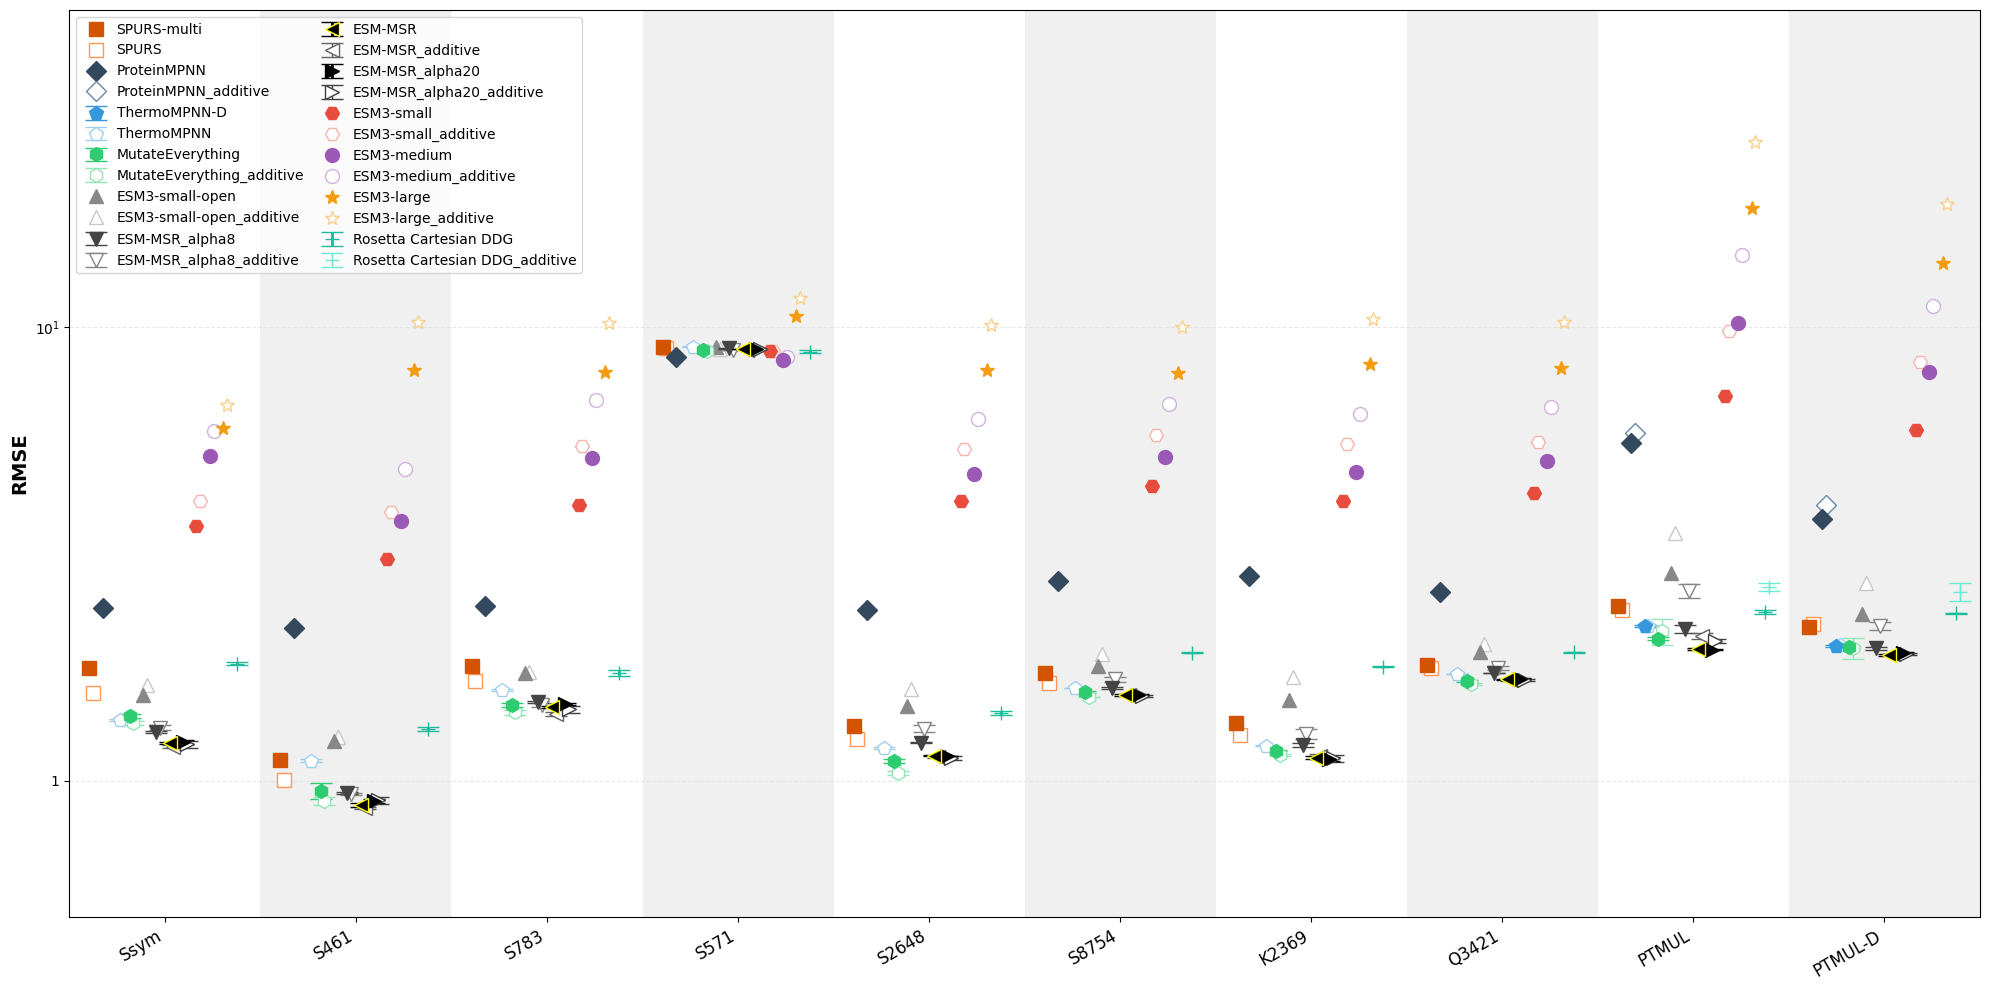

In [8]:
import importlib
importlib.reload(analysis_utils_msr)

df_rmse_custom = df_rmse.copy(deep=True)
df_rmse_custom.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_rmse_custom = df_rmse_custom

fig, ax = analysis_utils_msr.visualize_model_performance(df_rmse_custom.loc[['Ssym', 'S461', 'S783', 'S571', 'S2648', 'S8754', 'K2369', 'Q3421', 'PTMUL', 'PTMUL-D']], 
                                    title=None, ylabel='RMSE', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(0.5, 50), legend_loc='upper left', group_spread=0.07, yscale='symlog',
                                    colors=['#d35400','#34495e', '#3498db', '#2ecc71', "#888888", "#444444", "#222222", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [9]:
df_rho_custom = df_rho.copy(deep=True)
df_rho_custom.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_rho_custom = df_rho_custom

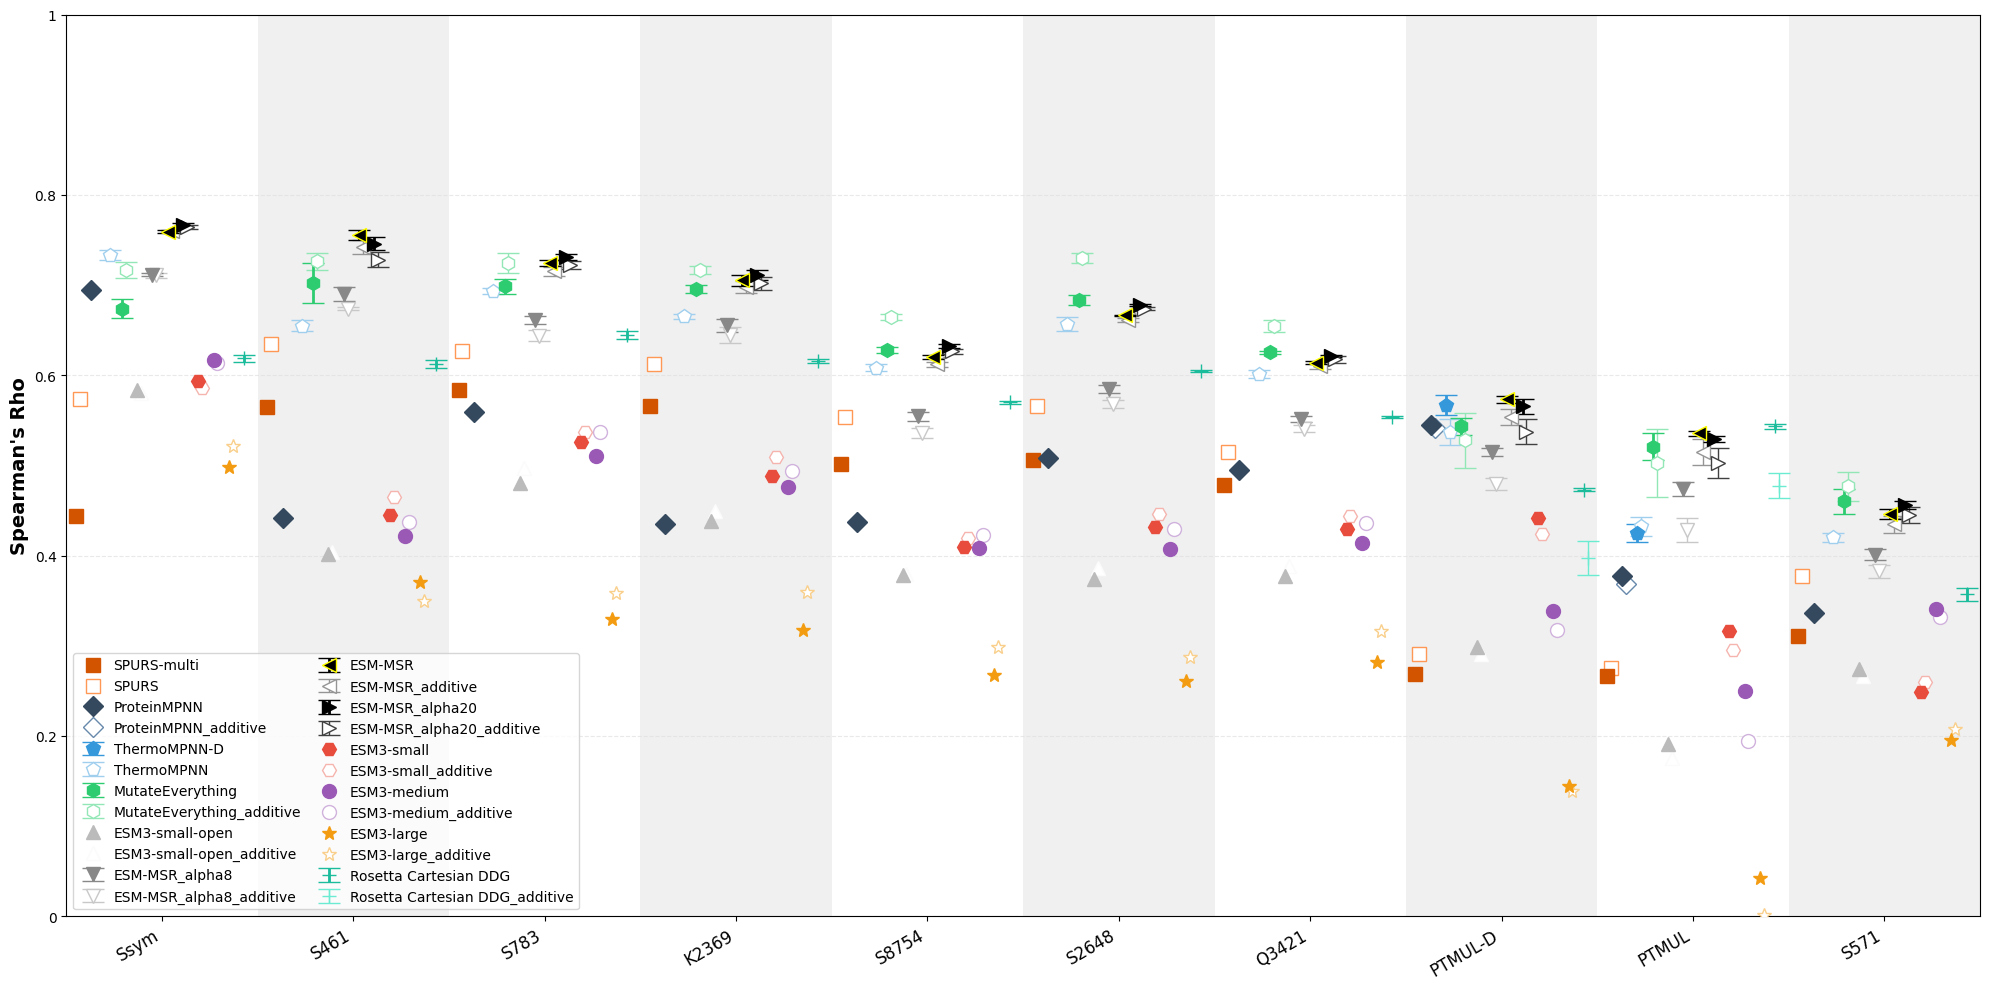

In [10]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_rho_custom.loc[['Ssym', 'S461', 'S783', 'K2369', 'S8754', 'S2648', 'Q3421', 'PTMUL-D', 'PTMUL', 'S571']], 
                                    title=None, ylabel='Spearman\'s Rho', figsize=(20, 10), highlighted_model='ESM-MSR', group_spread=0.08, ylim=(0,1),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", "#888888", "#555555", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c',], additive_offset=0.02)

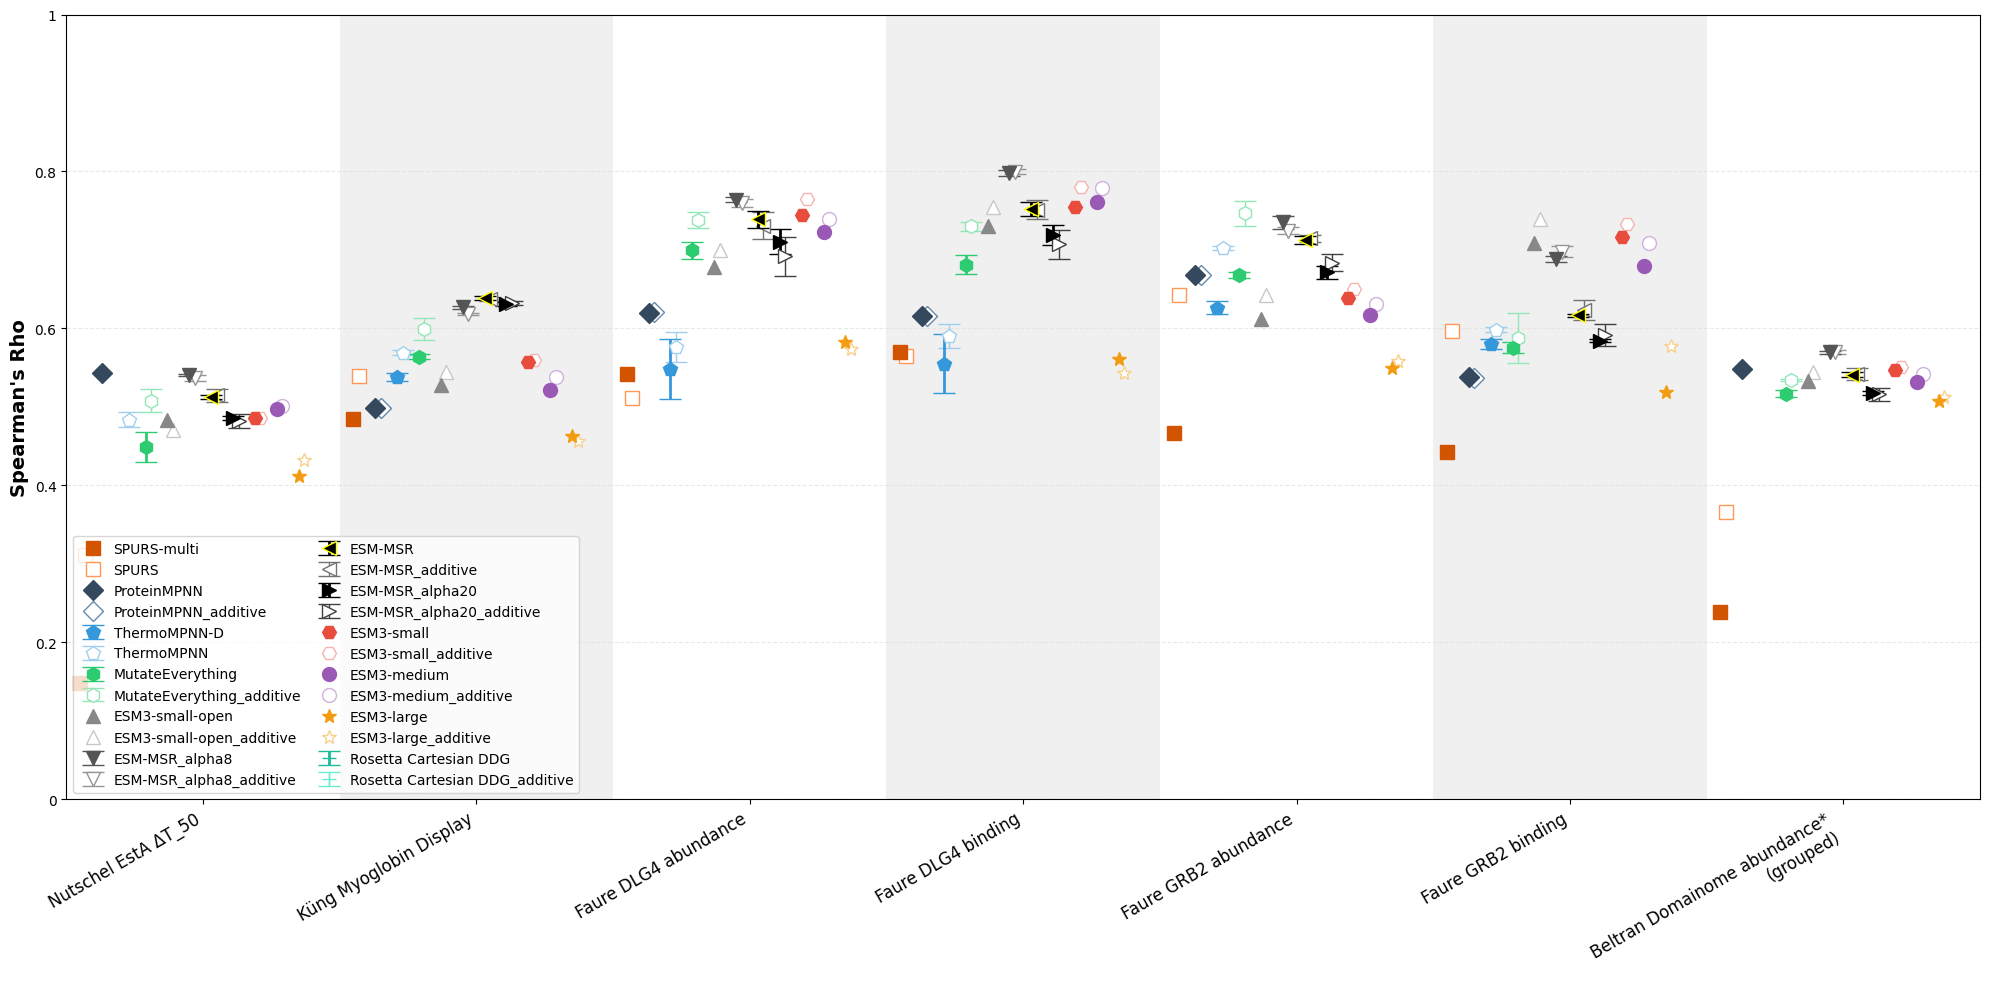

In [11]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_rho_custom.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding', 'Beltran Domainome abundance*\n(grouped)']], 
                                    title=None, ylabel='Spearman\'s Rho', highlighted_model='ESM-MSR', figsize=(20, 10), group_spread=0.08, ylim=(0,1),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [12]:
results['domainome']['SPURS'].dropna()

uid
A0A2R8Y422_PF00240_2_A27C   -0.318816
A0A2R8Y422_PF00240_2_A27D   -0.717765
A0A2R8Y422_PF00240_2_A27E   -0.406509
A0A2R8Y422_PF00240_2_A27F   -0.869076
A0A2R8Y422_PF00240_2_A27G   -0.712441
                               ...   
Q9Y6V0_PF05715_1058_W47R    -2.109951
Q9Y6V0_PF05715_1058_W47S    -2.348774
Q9Y6V0_PF05715_1058_W47T    -2.408581
Q9Y6V0_PF05715_1058_W47V    -2.442454
Q9Y6V0_PF05715_1058_W47Y    -1.276336
Name: SPURS, Length: 536145, dtype: float64

In [13]:
df_gain_custom = df_gain_per_mut.copy(deep=True)
df_gain_custom.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_gain_custom = df_gain_custom

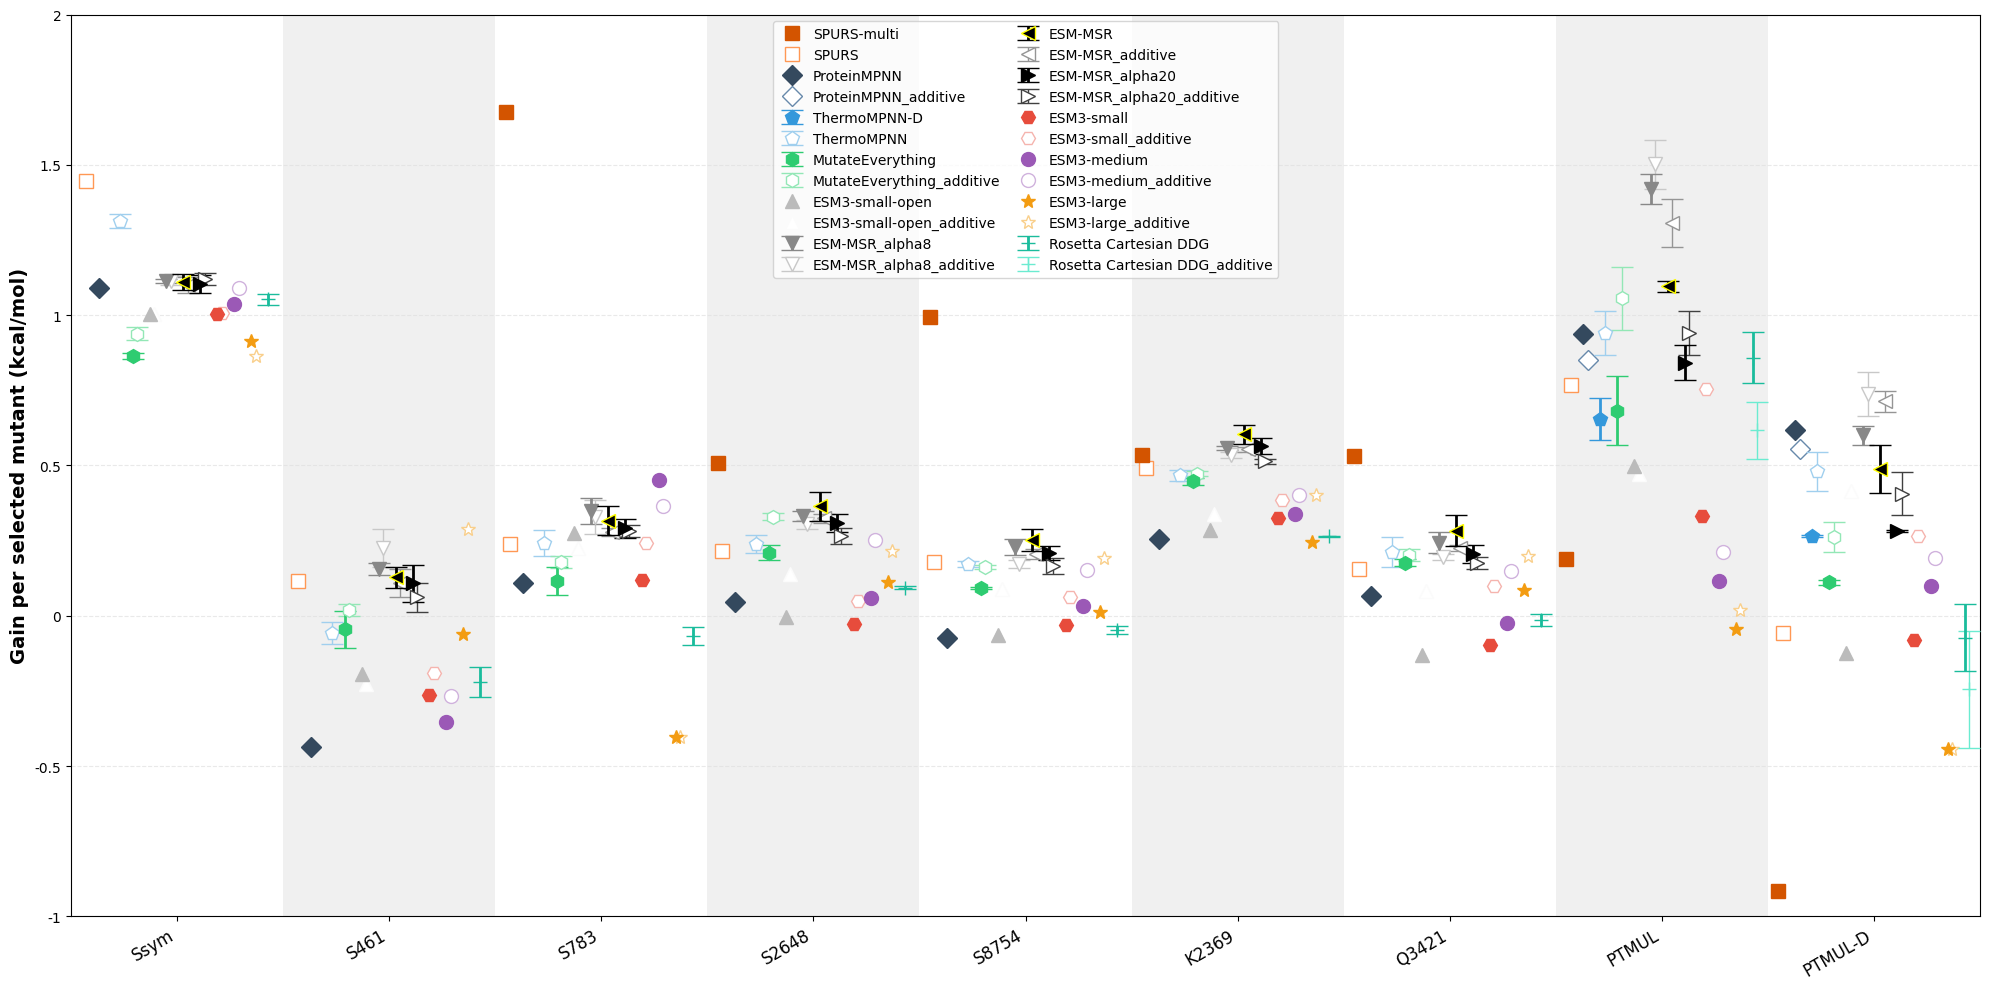

In [14]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Ssym', 'S461', 'S783', 'S2648', 'S8754', 'K2369', 'Q3421', 'PTMUL', 'PTMUL-D']], #'S571'
                                    title=None, ylabel='Gain per selected mutant (kcal/mol)', figsize=(20, 10), highlighted_model='ESM-MSR', group_spread=0.08, ylim=(-1, 2), legend_loc='upper center',
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", "#888888", "#555555", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c',], additive_offset=0.02)

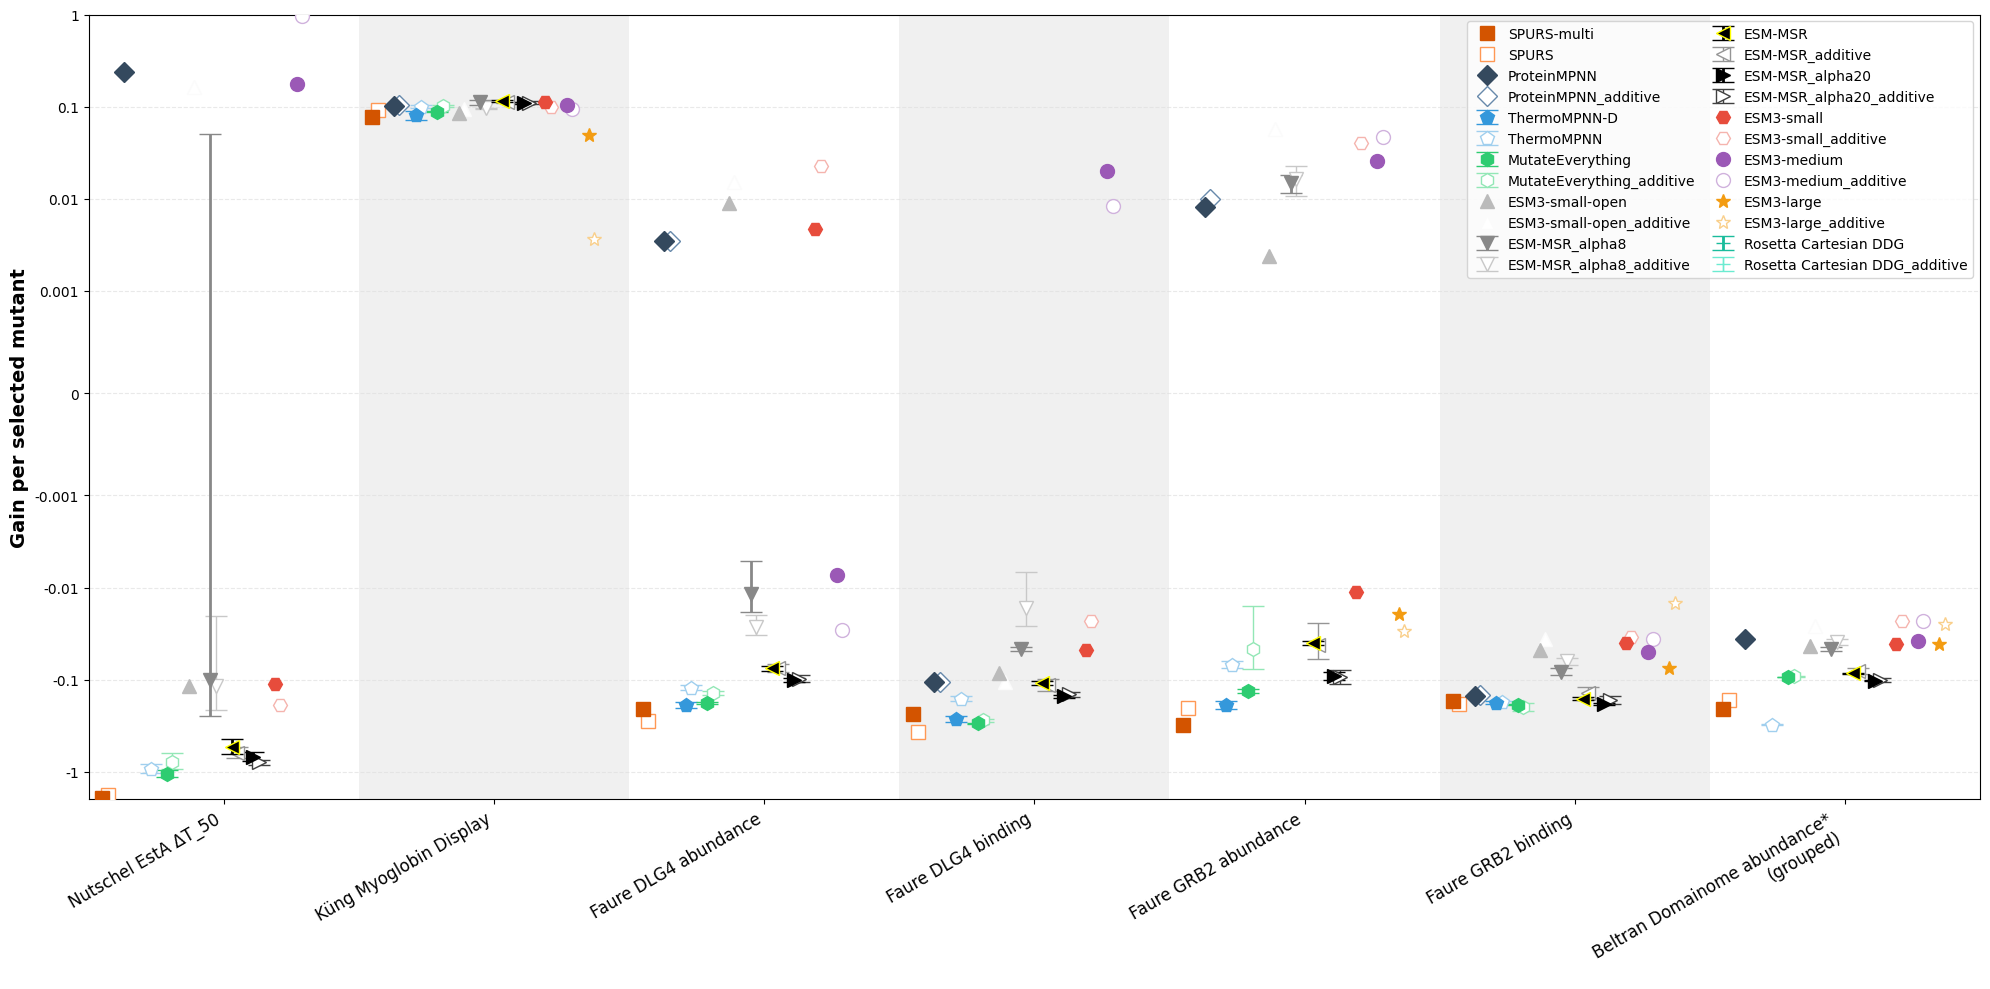

In [15]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding', 'Beltran Domainome abundance*\n(grouped)']], 
                                    title=None, ylabel='Gain per selected mutant', highlighted_model='ESM-MSR', group_spread=0.08, figsize=(20, 10), ylim=(-2, 1), yscale='symlog', legend_loc='upper right',
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", "#888888", "#555555", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [16]:
df_gain_custom = df_gain_all.copy(deep=True)
df_gain_custom.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_gain_custom = df_gain_custom

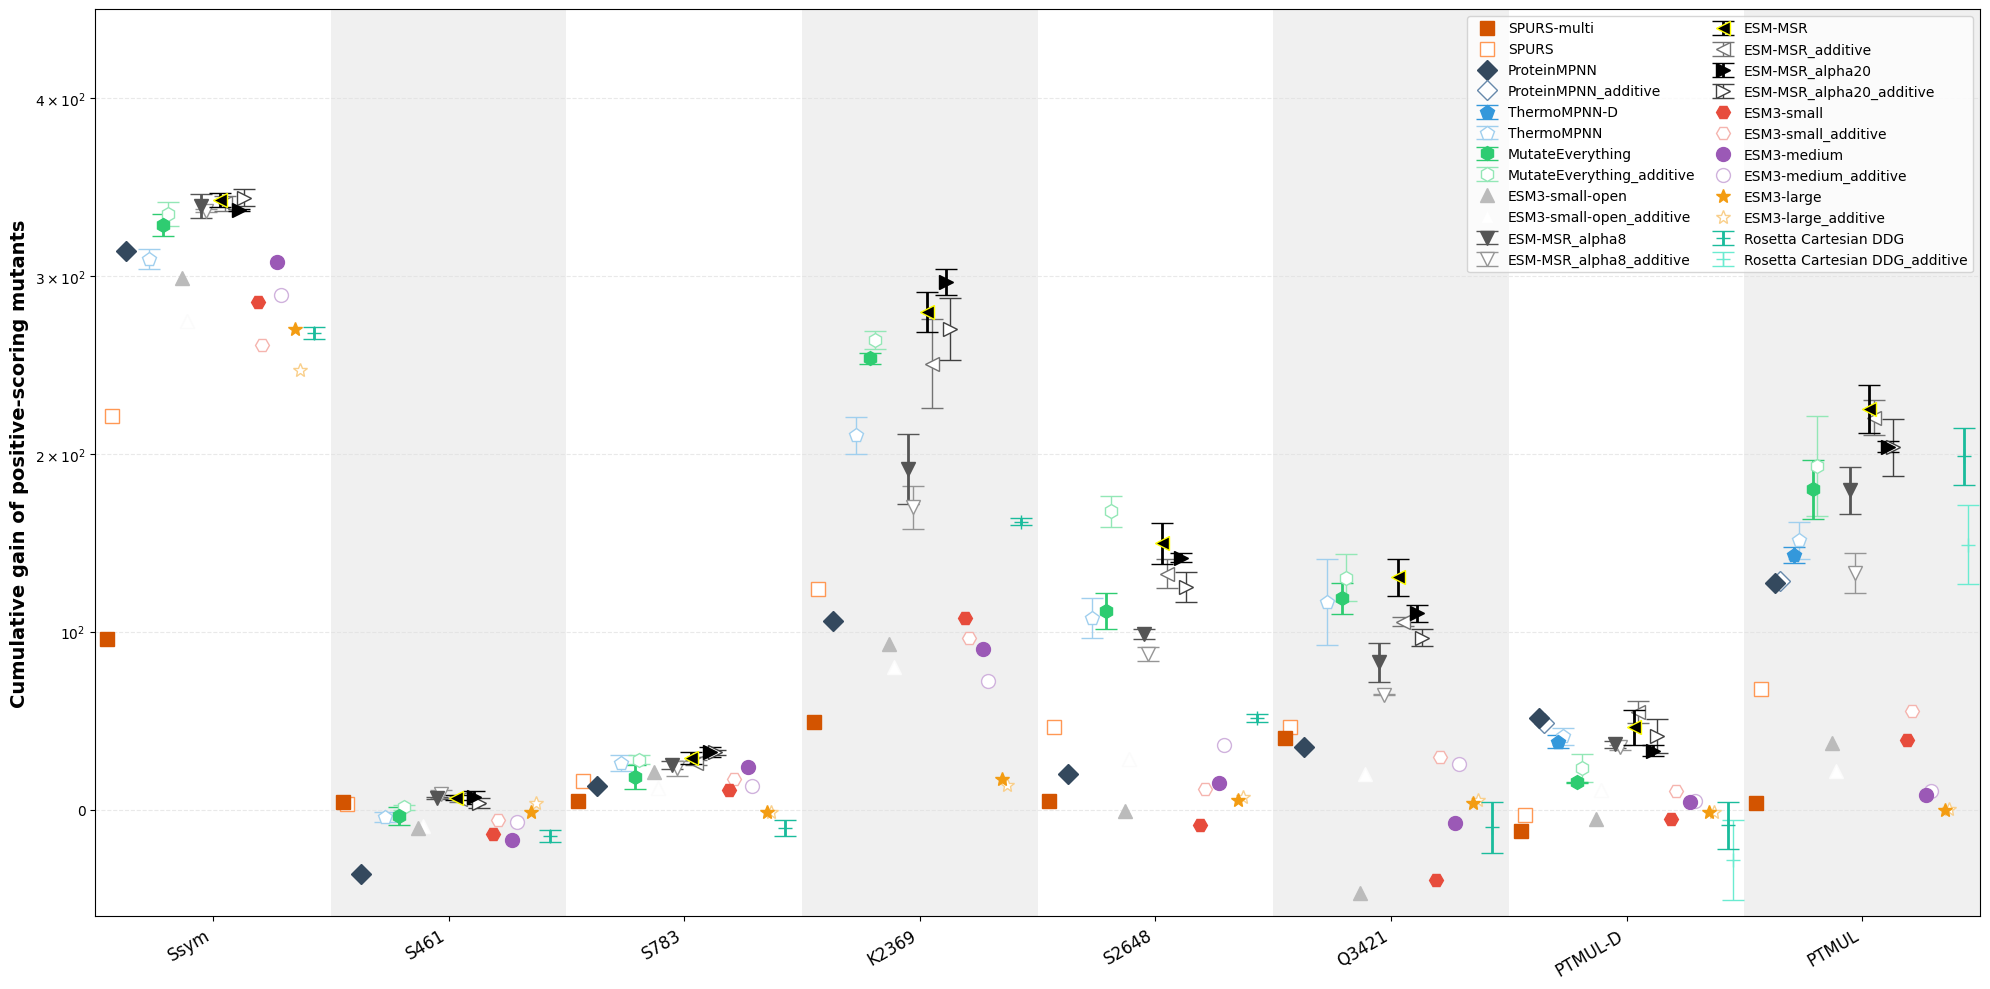

In [17]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Ssym', 'S461', 'S783', 'K2369', 'S2648', 'Q3421', 'PTMUL-D', 'PTMUL']], #'S8754', , 'S571'
                                    title=None, ylabel='Cumulative gain of positive-scoring mutants', figsize=(20, 10), highlighted_model='ESM-MSR', group_spread=0.08, ylim=(-60, 450), legend_loc='upper right',
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c',], additive_offset=0.02)

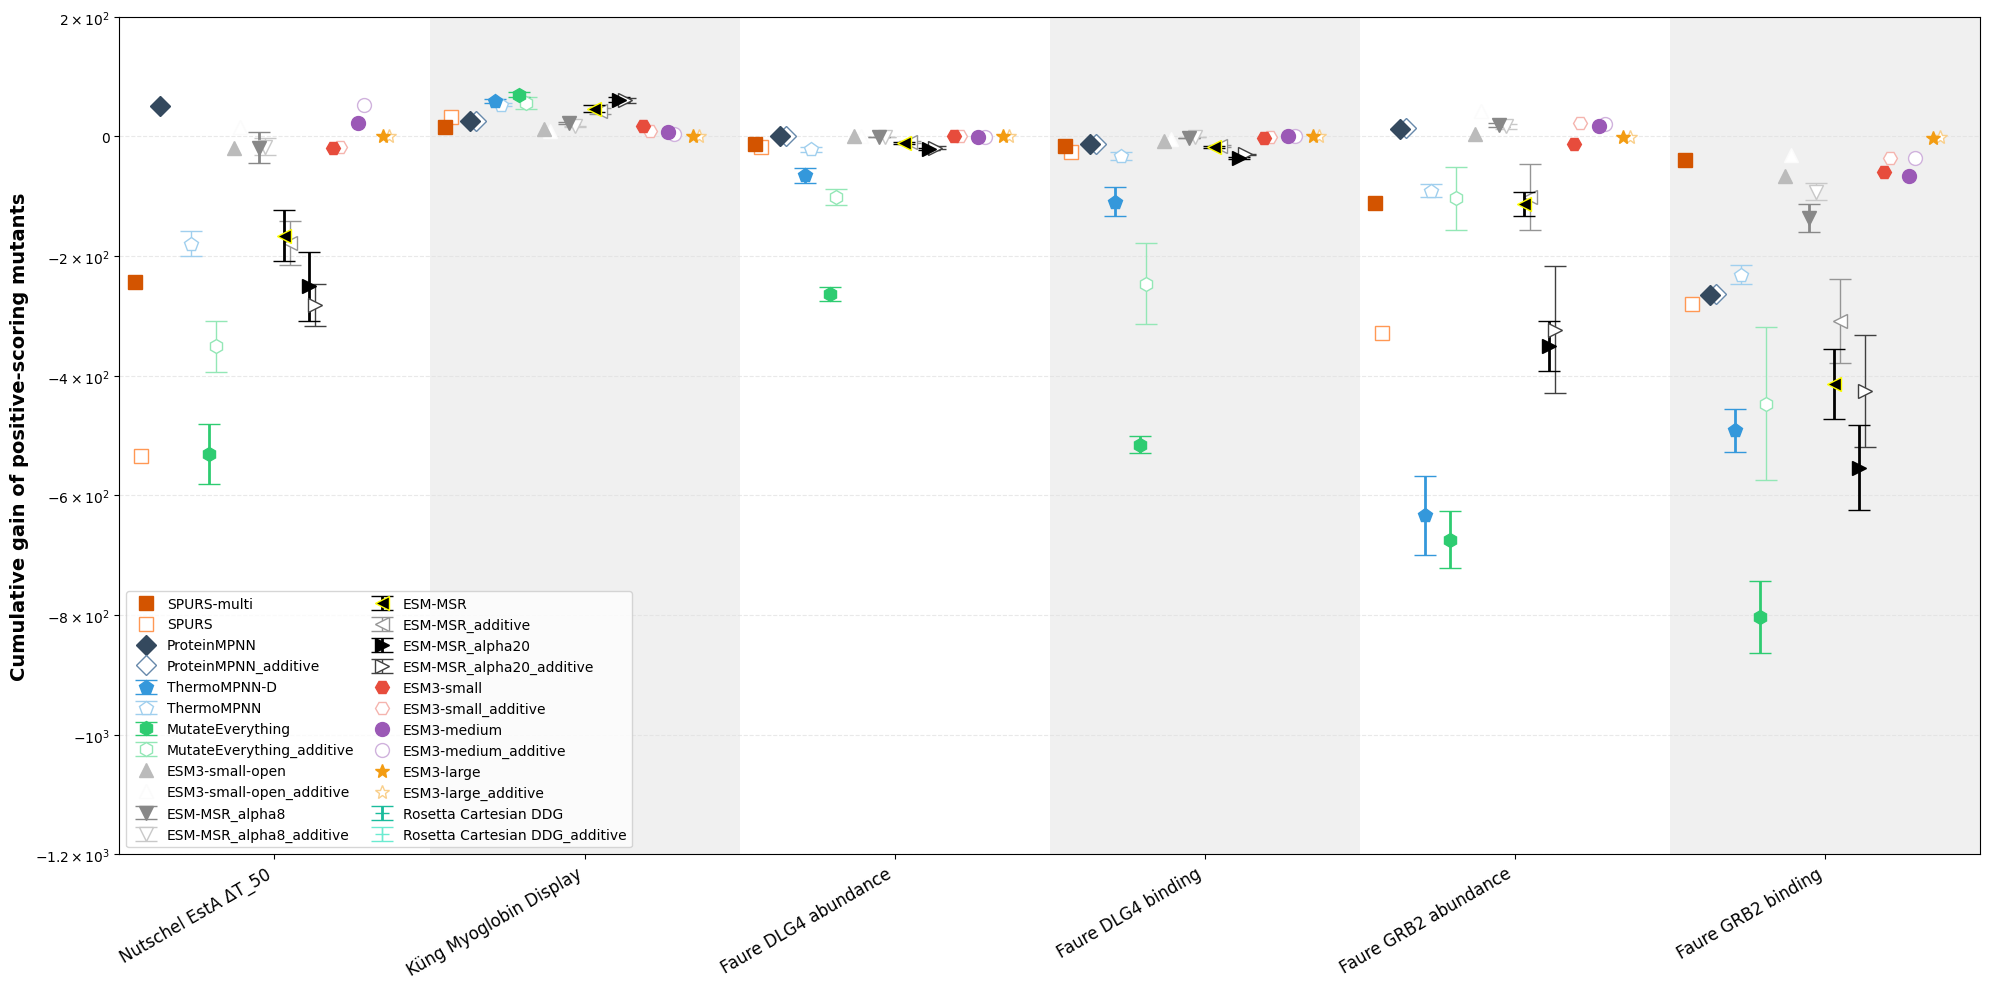

In [18]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding']], #'Beltran Domainome abundance*\n(grouped)'
                                    title=None, ylabel='Cumulative gain of positive-scoring mutants', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(-1200, 200), group_spread=0.08,
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", "#888888", "#555555", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [19]:
df_ndcg_custom_pos = df_ndcg_pos.copy(deep=True)
df_ndcg_custom_pos.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_ndcg_custom_pos = df_ndcg_custom_pos

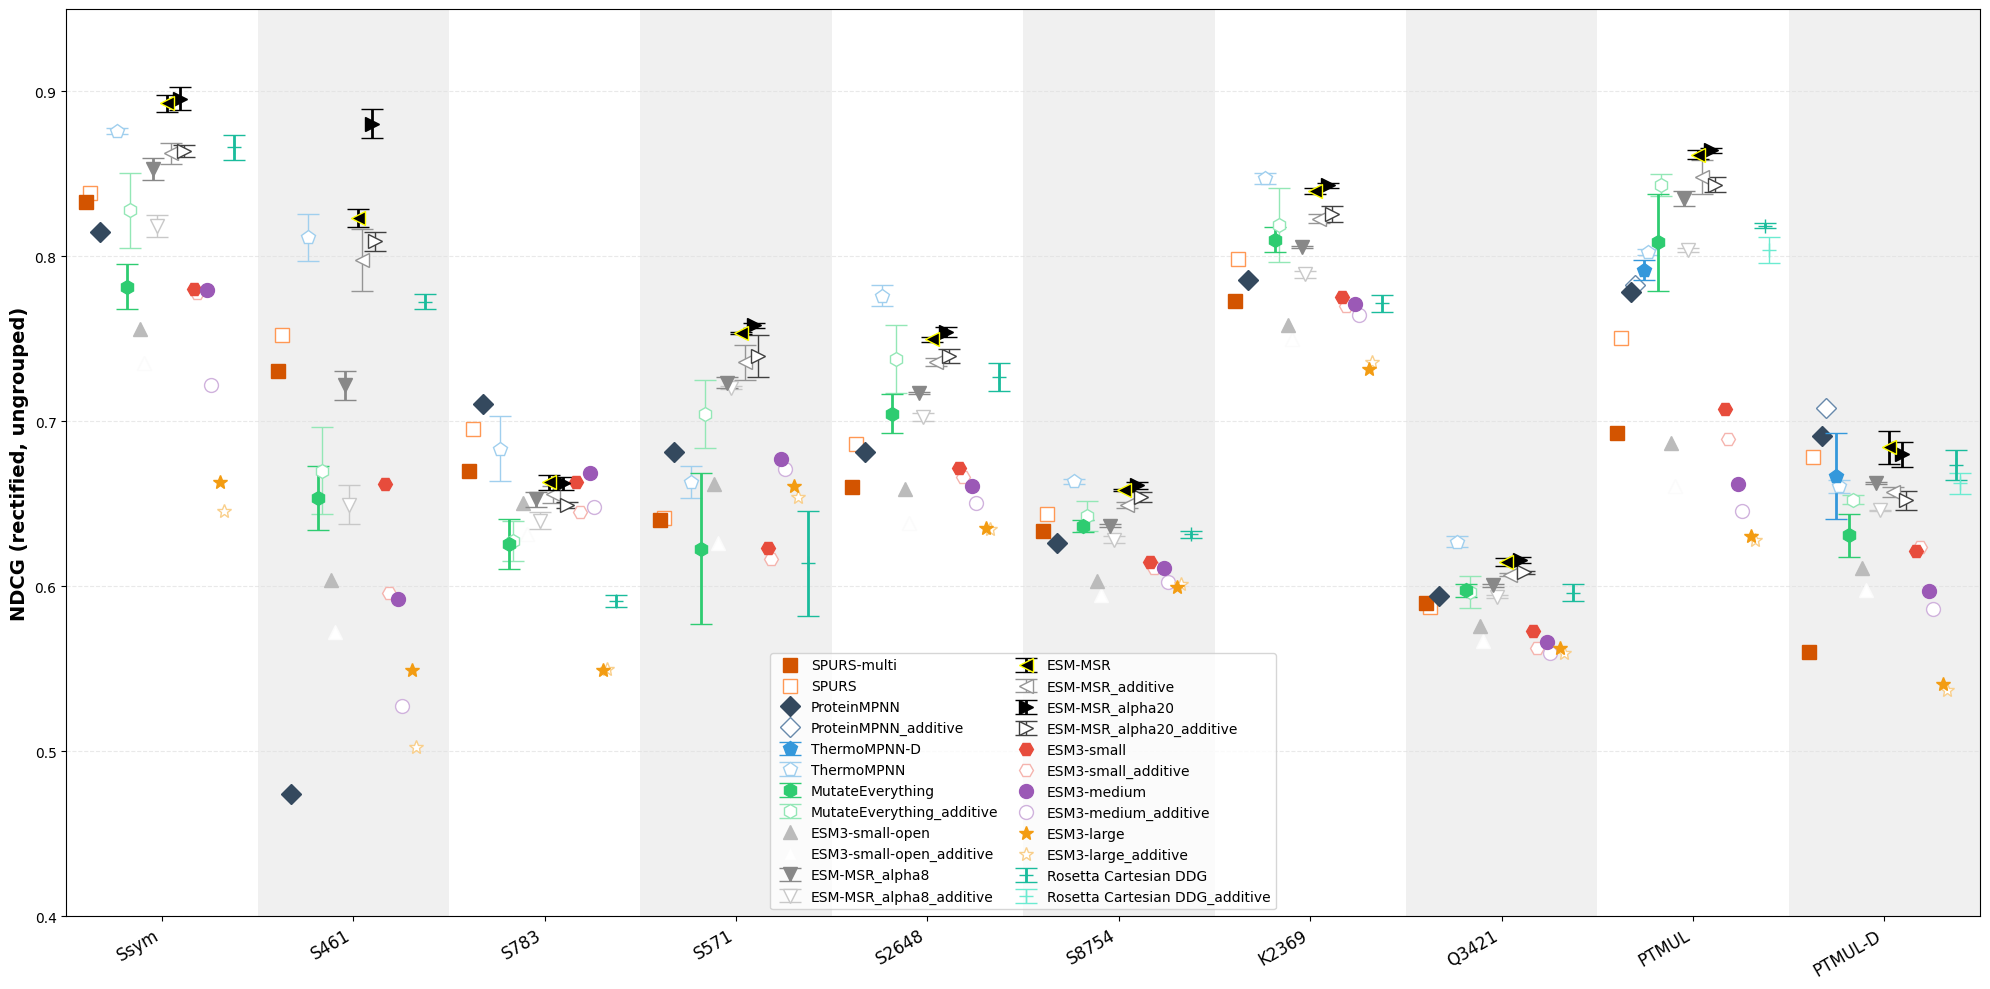

In [20]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_ndcg_custom_pos.loc[['Ssym', 'S461', 'S783', 'S571', 'S2648', 'S8754', 'K2369', 'Q3421', 'PTMUL', 'PTMUL-D']], 
                                    title=None, ylabel='NDCG (rectified, ungrouped)', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(0.4, 0.95), group_spread=(0.07),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", "#888888", "#555555", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02, legend_loc='lower center')

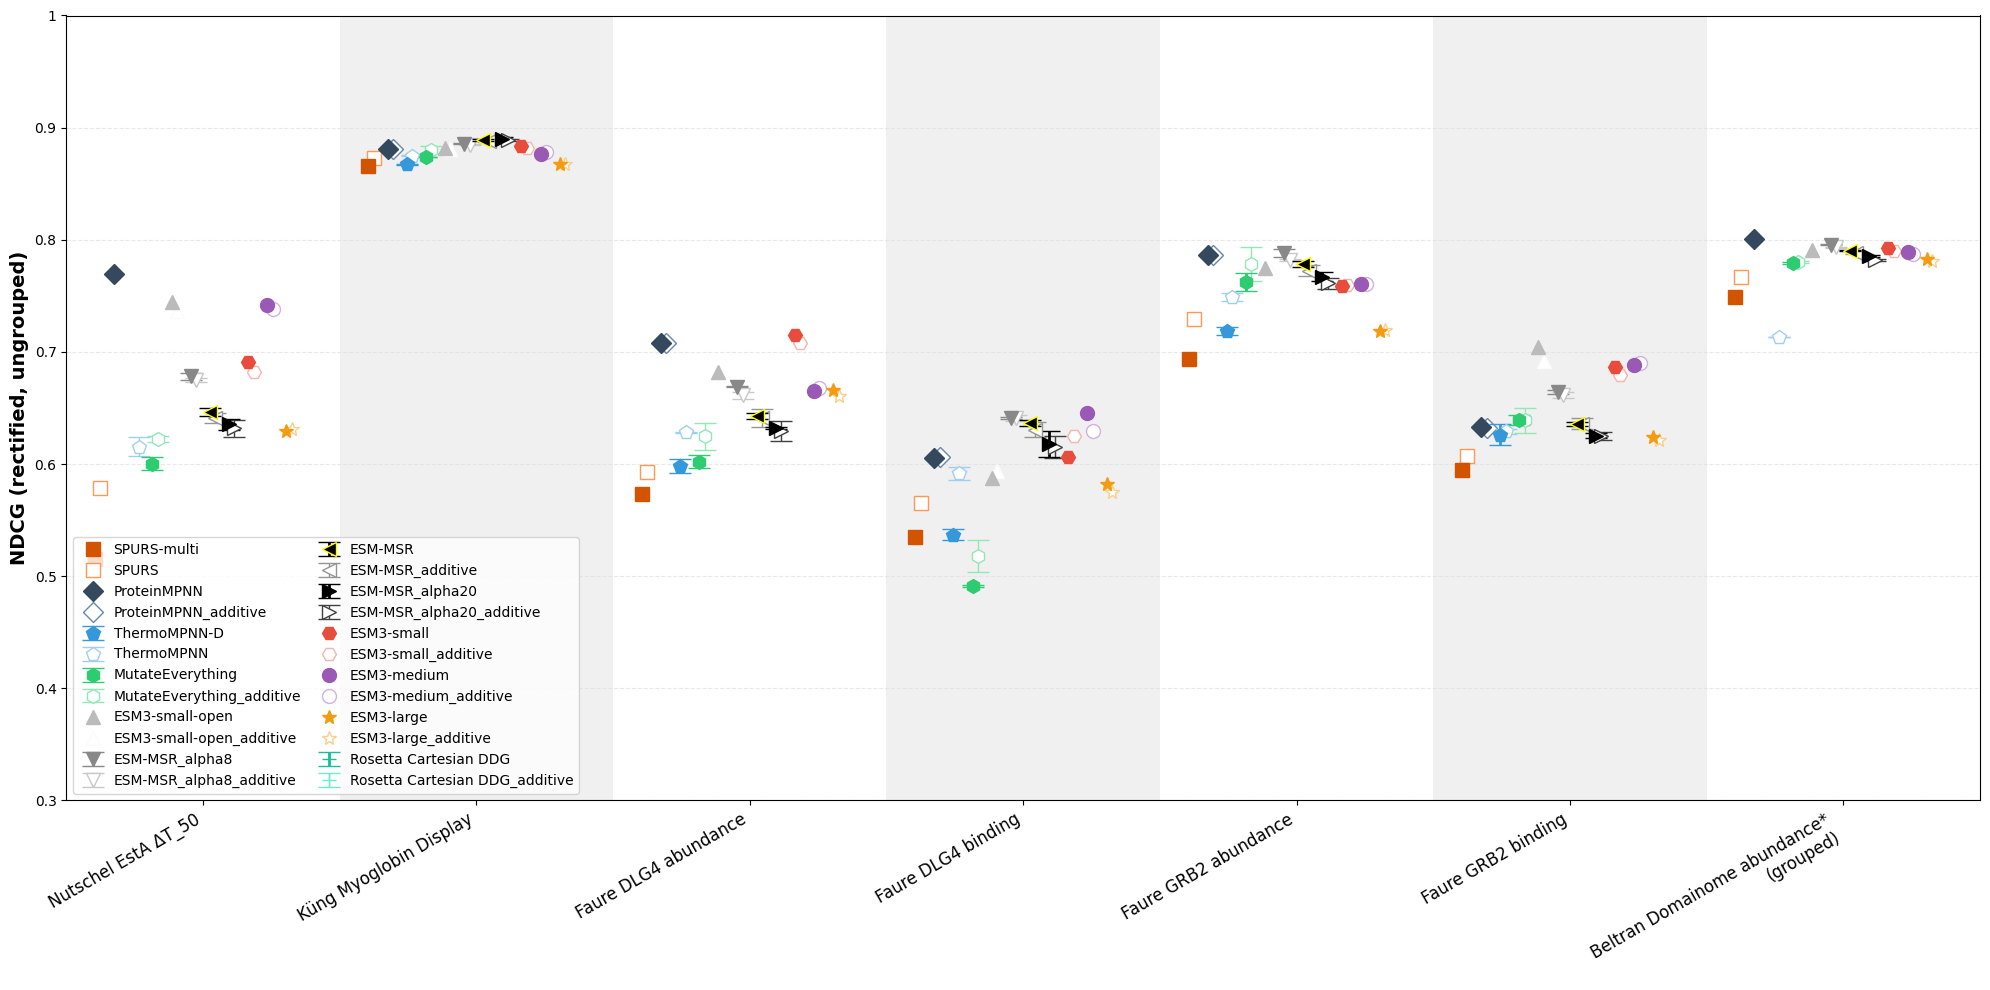

In [21]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_ndcg_custom_pos.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding', 'Beltran Domainome abundance*\n(grouped)']], 
                                    title=None, ylabel='NDCG (rectified, ungrouped)', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(0.3,1), group_spread=(0.07),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", "#888888", "#555555", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02, legend_loc='lower left')

In [22]:
df_ndcg_grouped_custom_pos = df_ndcg_grouped_pos.copy(deep=True)
df_ndcg_grouped_custom_pos.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_ndcg_grouped_custom_pos = df_ndcg_grouped_custom_pos

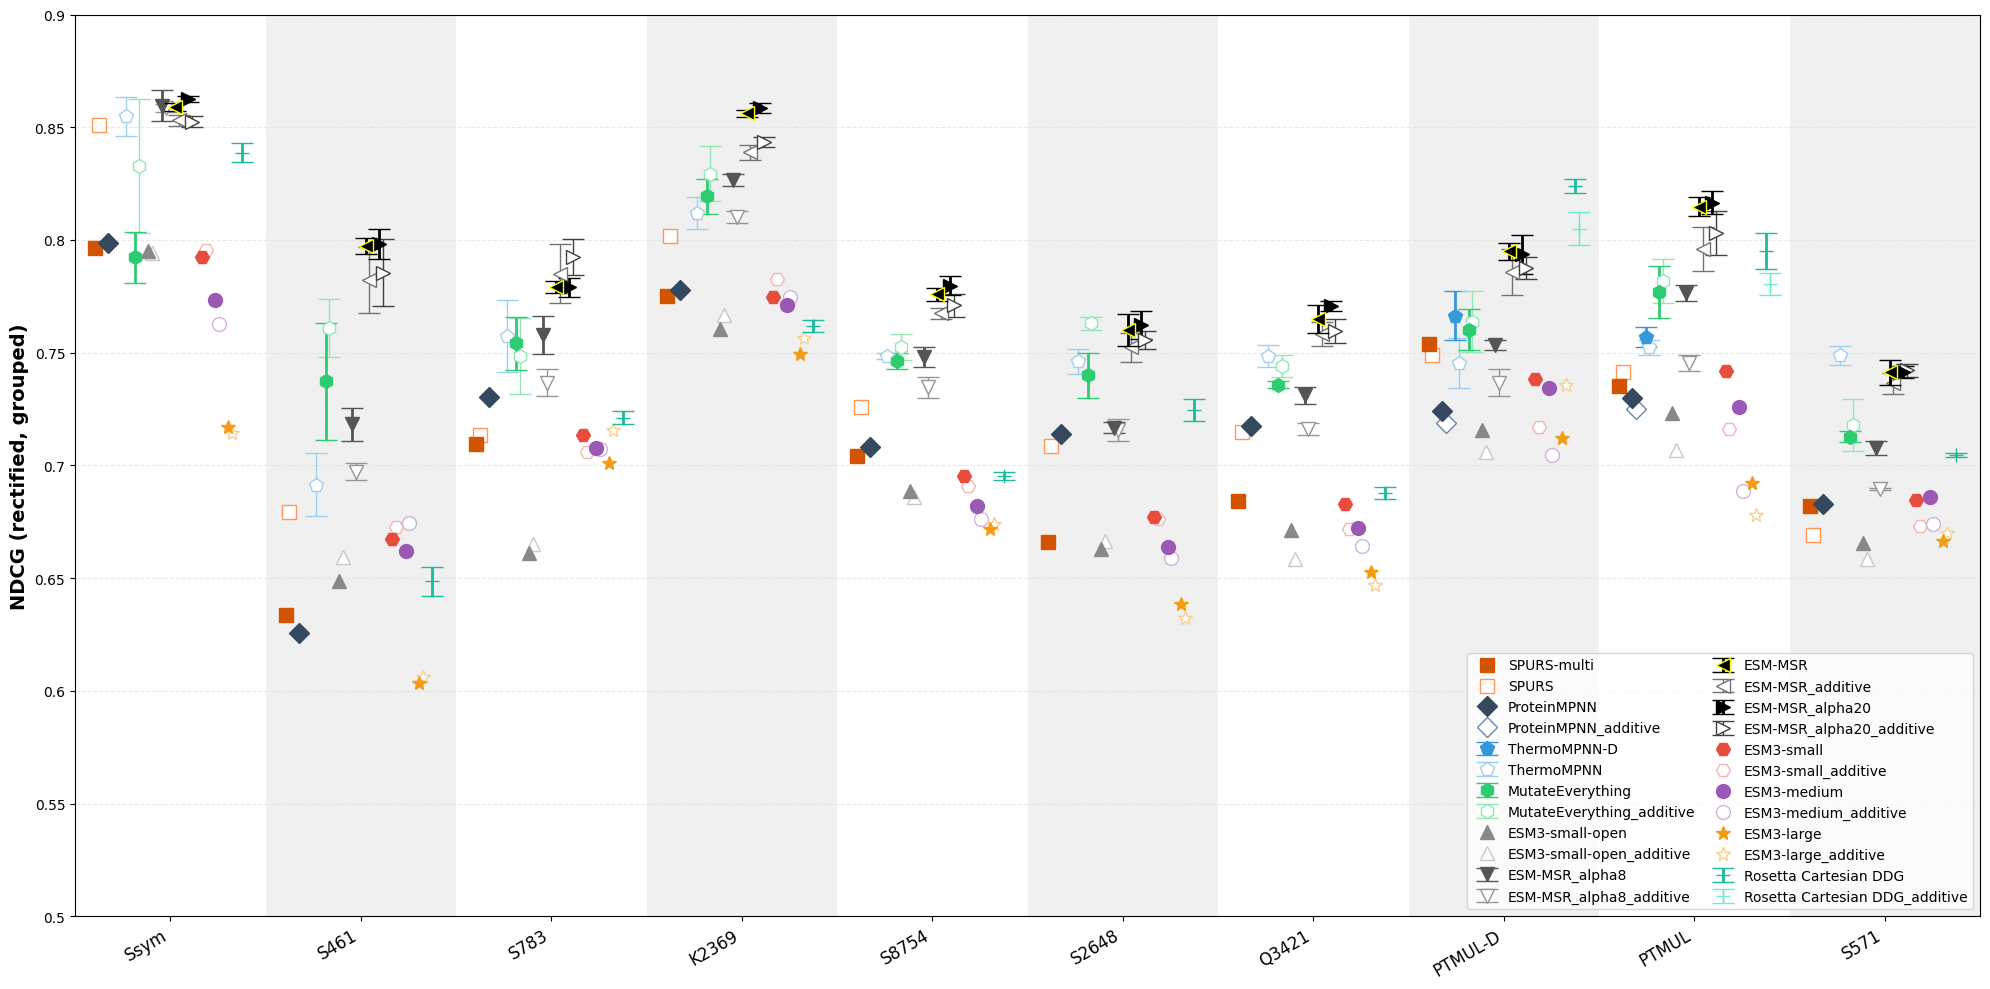

In [23]:
import analysis_utils_msr
fig, ax = analysis_utils_msr.visualize_model_performance(df_ndcg_grouped_custom_pos.loc[['Ssym', 'S461', 'S783', 'K2369', 'S8754', 'S2648', 'Q3421', 'PTMUL-D', 'PTMUL', 'S571']], 
                                    title=None, ylabel='NDCG (rectified, grouped)', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(0.5, 0.9), legend_loc='lower right', group_spread=(0.07),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

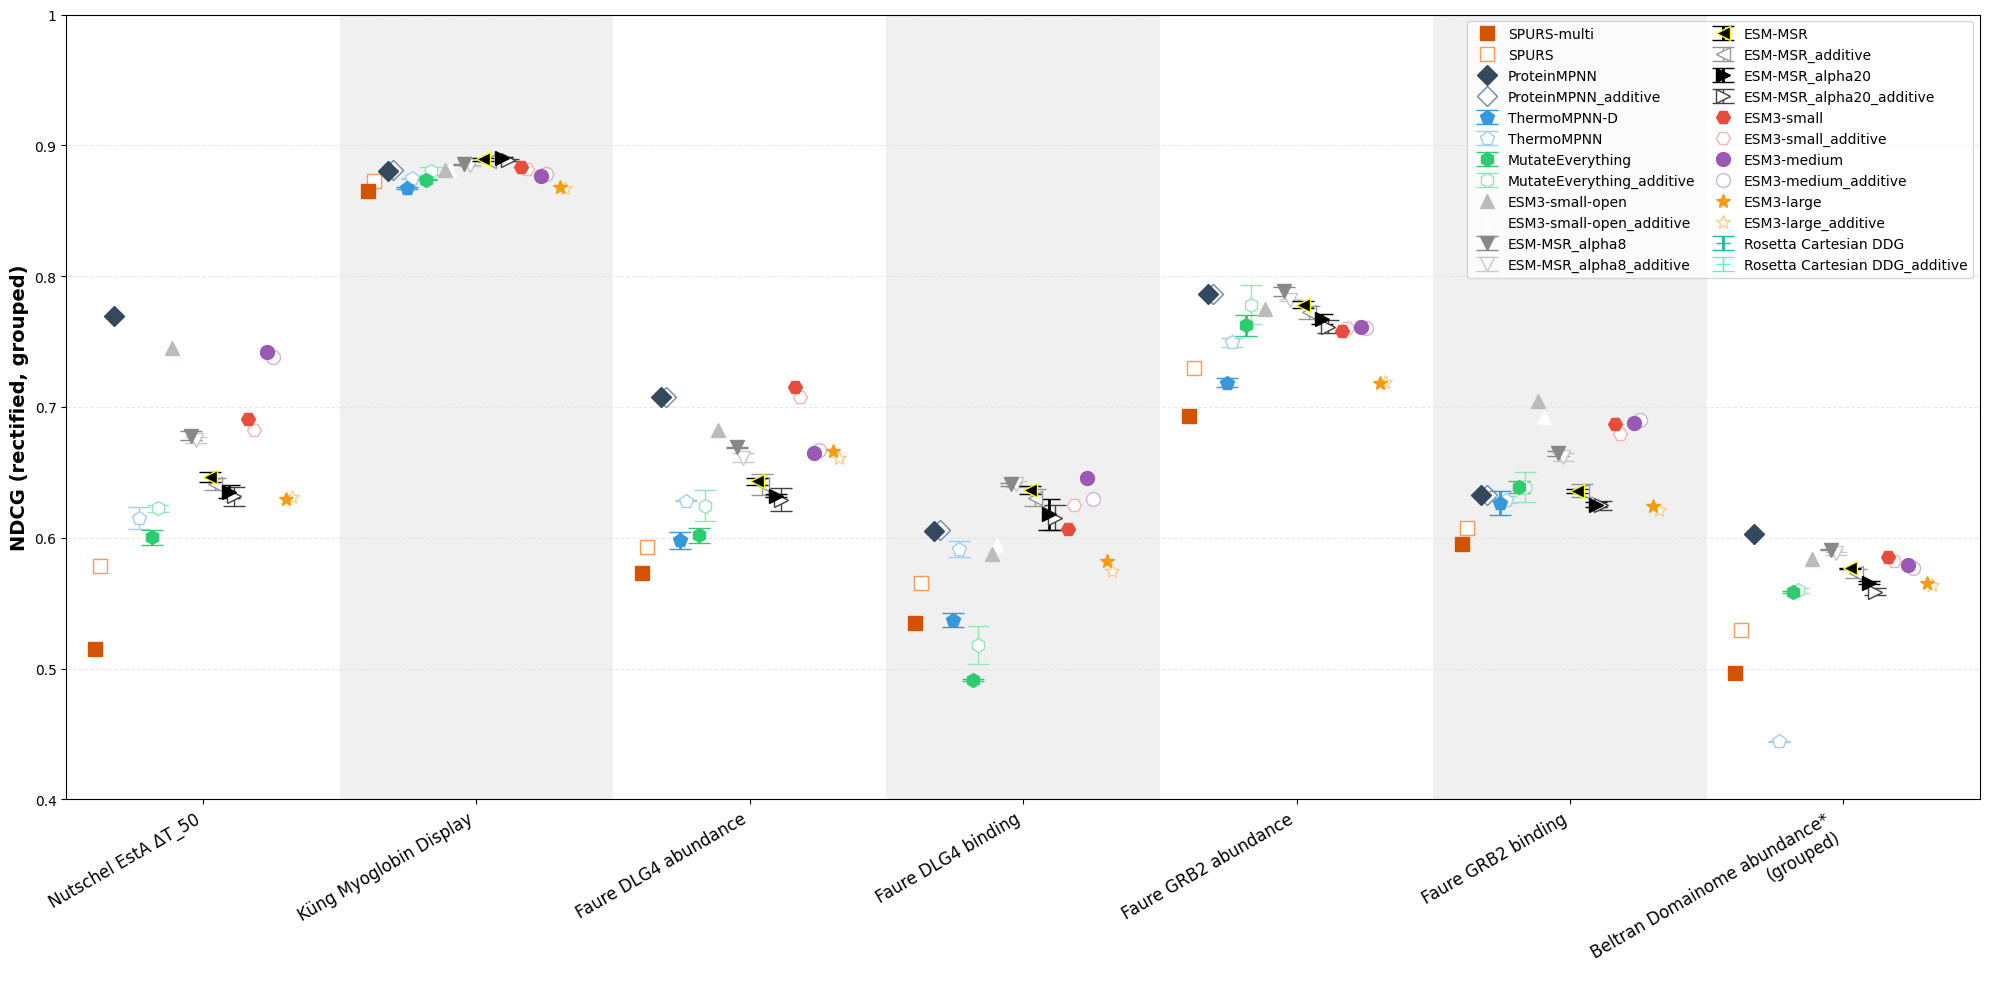

In [24]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_ndcg_grouped_custom_pos.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding', 'Beltran Domainome abundance*\n(grouped)']], 
                                    title=None, ylabel='NDCG (rectified, grouped)', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(0.4,1), legend_loc='upper right', group_spread=(0.07),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", "#888888", "#555555", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [25]:
results['ssym']

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,mut_type,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,code,ground_truth
uid,,,,,,,,,,,,,,,,,,,,,
107LA_G44S,-0.160820,-0.615181,1.583663,0.500451,0.346556,0.318611,0.190628,0.271743,0.111830,0.394149,...,7.582031,0.325510,0.326190,0.320068,G44S,0.5,-0.5,0.5,1L63,0.5
108LA_I44S,-0.291302,-0.973445,0.269440,-0.364794,-0.296963,-0.353899,-0.103046,-0.120200,-0.116985,-0.140712,...,6.464844,-0.987075,-0.987075,-0.987075,I44S,-0.3,0.3,-0.3,1L63,-0.3
109LA_K44S,-0.422427,-0.758919,-1.048504,-0.225160,-0.214863,-0.260943,-0.006564,0.071386,-0.061439,0.141733,...,8.427734,-0.532653,-0.609524,-0.607483,K44S,-0.2,0.2,-0.2,1L63,-0.2
110LA_L44S,-0.415150,-1.015740,1.255608,-0.325828,-0.267427,-0.374694,0.092205,0.087641,0.012798,0.195901,...,7.570312,-0.949320,-0.944898,-0.949320,L44S,-0.4,0.4,-0.4,1L63,-0.4
111LA_N44S,-0.234954,-0.706592,0.218113,0.081656,0.061483,0.033652,0.196107,0.074409,0.088409,0.208146,...,7.398438,-0.267347,-0.267347,-0.267347,N44S,0.1,-0.1,0.1,1L63,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5PTIA_F22A,-2.662874,-2.179212,-3.331647,-1.570580,-1.759823,-1.818358,-1.835210,-1.570412,-1.562886,-1.275162,...,-4.562500,-3.078912,-3.084694,-3.080272,F22A,-1.2,1.2,-1.2,5PTI,-1.2
5PTIA_F45A,-2.624974,-2.426673,-5.421578,-2.416369,-2.456740,-2.487764,-4.169949,-3.270841,-4.136079,-3.694101,...,-7.070312,-3.932993,-3.933333,-3.935374,F45A,-6.9,6.9,-6.9,5PTI,-6.9
5PTIA_N43G,-0.614857,-0.857467,-5.378171,-1.027751,-1.523070,-0.658061,-2.210457,-2.263006,-1.808211,-1.308090,...,-5.832031,-4.677551,-4.680612,-5.269728,N43G,-5.7,5.7,-5.7,5PTI,-5.7


In [26]:
results['ssym']

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,mut_type,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,code,ground_truth
uid,,,,,,,,,,,,,,,,,,,,,
107LA_G44S,-0.160820,-0.615181,1.583663,0.500451,0.346556,0.318611,0.190628,0.271743,0.111830,0.394149,...,7.582031,0.325510,0.326190,0.320068,G44S,0.5,-0.5,0.5,1L63,0.5
108LA_I44S,-0.291302,-0.973445,0.269440,-0.364794,-0.296963,-0.353899,-0.103046,-0.120200,-0.116985,-0.140712,...,6.464844,-0.987075,-0.987075,-0.987075,I44S,-0.3,0.3,-0.3,1L63,-0.3
109LA_K44S,-0.422427,-0.758919,-1.048504,-0.225160,-0.214863,-0.260943,-0.006564,0.071386,-0.061439,0.141733,...,8.427734,-0.532653,-0.609524,-0.607483,K44S,-0.2,0.2,-0.2,1L63,-0.2
110LA_L44S,-0.415150,-1.015740,1.255608,-0.325828,-0.267427,-0.374694,0.092205,0.087641,0.012798,0.195901,...,7.570312,-0.949320,-0.944898,-0.949320,L44S,-0.4,0.4,-0.4,1L63,-0.4
111LA_N44S,-0.234954,-0.706592,0.218113,0.081656,0.061483,0.033652,0.196107,0.074409,0.088409,0.208146,...,7.398438,-0.267347,-0.267347,-0.267347,N44S,0.1,-0.1,0.1,1L63,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5PTIA_F22A,-2.662874,-2.179212,-3.331647,-1.570580,-1.759823,-1.818358,-1.835210,-1.570412,-1.562886,-1.275162,...,-4.562500,-3.078912,-3.084694,-3.080272,F22A,-1.2,1.2,-1.2,5PTI,-1.2
5PTIA_F45A,-2.624974,-2.426673,-5.421578,-2.416369,-2.456740,-2.487764,-4.169949,-3.270841,-4.136079,-3.694101,...,-7.070312,-3.932993,-3.933333,-3.935374,F45A,-6.9,6.9,-6.9,5PTI,-6.9
5PTIA_N43G,-0.614857,-0.857467,-5.378171,-1.027751,-1.523070,-0.658061,-2.210457,-2.263006,-1.808211,-1.308090,...,-5.832031,-4.677551,-4.680612,-5.269728,N43G,-5.7,5.7,-5.7,5PTI,-5.7


In [27]:
df_sym = results['ssym'].reset_index()
df_sym['wt_code'] = df_sym['code']
df_sym['code'] = df_sym['uid'].apply(lambda x: x.split('_')[0][:-1])
#df_sym['position'] = df_sym['mut_type'].str[1:-1].astype(int)
df_sym_rev = df_sym.loc[df_sym['code']!=df_sym['wt_code']]
df_sym_for = df_sym.loc[df_sym['code']==df_sym['wt_code']]
df_sym_for['uid2'] = df_sym_for['wt_code'] + '_' + df_sym_for['mut_type']
df_sym_for = df_sym_for.set_index('uid2')
df_sym_for = df_sym_for.drop(columns=['uid', 'code', 'wt_code', 'mut_type'])
df_sym_for

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,ground_truth
uid2,,,,,,,,,,,,,,,,,,,,,
1AMQ_C180Y,-0.517308,-0.658546,-5.057691,-1.085750,-0.806029,-1.054105,-1.122820,-0.987658,-0.971506,-0.852858,...,-11.781250,-8.772461,-6.867188,-1.932313,-1.809864,-2.290136,-2.3,2.3,-2.3,-2.3
1AMQ_C180F,-0.352569,-0.364684,-5.282454,-0.825052,-0.832960,-0.773816,-0.752259,-0.684896,-0.745625,-0.362731,...,-10.898438,-9.365234,-7.343750,-8.001020,-9.232993,-9.225170,-1.6,1.6,-1.6,-1.6
1AMQ_C180W,-0.464654,-0.609704,-5.405746,-1.312649,-1.302561,-1.207341,-1.158809,-0.911358,-0.694558,-1.203414,...,-12.703125,-11.656250,-9.531250,-1.402381,-1.363605,-1.690476,-3.9,3.9,-3.9,-3.9
1AMQ_C180S,-0.412744,-1.012127,-2.240716,-0.010812,0.081806,-0.051382,-0.206840,-0.709537,0.018058,0.207002,...,-3.992188,-7.476562,-4.812500,-0.915646,-0.936054,-0.941156,-1.9,1.9,-1.9,-1.9
1BNI_S91A,0.037341,-0.477785,-4.256861,-1.157090,-1.003748,-0.923675,-0.879816,-0.594016,-0.517364,-0.869824,...,-6.093750,-5.468750,-3.546875,0.051020,0.521429,0.718027,-1.8,1.8,-1.8,-1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5PTI_Y23A,-2.719429,-1.992676,-5.349803,-2.879154,-2.443834,-2.917407,-3.310062,-2.876374,-3.062140,-3.426815,...,-10.852783,-11.290222,-6.406250,-4.778912,-4.779252,-4.779252,-5.9,5.9,-5.9,-5.9
5PTI_F22A,-2.662874,-2.179212,-3.331647,-1.570580,-1.759823,-1.818358,-1.835210,-1.570412,-1.562886,-1.275162,...,-3.742188,-7.775391,-4.562500,-3.078912,-3.084694,-3.080272,-1.2,1.2,-1.2,-1.2
5PTI_F45A,-2.624974,-2.426673,-5.421578,-2.416369,-2.456740,-2.487764,-4.169949,-3.270841,-4.136079,-3.694101,...,-11.834717,-11.501465,-7.070312,-3.932993,-3.933333,-3.935374,-6.9,6.9,-6.9,-6.9


In [28]:
df_sym_rev['uid2'] = df_sym_rev['wt_code'] + '_' + df_sym_rev['mut_type'].str[-1] + df_sym_rev['mut_type'].str[1:-1] + df_sym_rev['mut_type'].str[0]
df_sym_rev = df_sym_rev.set_index('uid2')
df_sym_rev = df_sym_rev.drop(columns=['uid', 'code', 'wt_code', 'mut_type'])
df_sym_rev

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,ground_truth
uid2,,,,,,,,,,,,,,,,,,,,,
1L63_S44G,-0.160820,-0.615181,1.583663,0.500451,0.346556,0.318611,0.190628,0.271743,0.111830,0.394149,...,1.492188,2.501953,7.582031,0.325510,0.326190,0.320068,0.5,-0.5,0.5,0.5
1L63_S44I,-0.291302,-0.973445,0.269440,-0.364794,-0.296963,-0.353899,-0.103046,-0.120200,-0.116985,-0.140712,...,-0.635254,1.247559,6.464844,-0.987075,-0.987075,-0.987075,-0.3,0.3,-0.3,-0.3
1L63_S44K,-0.422427,-0.758919,-1.048504,-0.225160,-0.214863,-0.260943,-0.006564,0.071386,-0.061439,0.141733,...,-1.236084,4.056641,8.427734,-0.532653,-0.609524,-0.607483,-0.2,0.2,-0.2,-0.2
1L63_S44L,-0.415150,-1.015740,1.255608,-0.325828,-0.267427,-0.374694,0.092205,0.087641,0.012798,0.195901,...,-0.160034,1.719727,7.570312,-0.949320,-0.944898,-0.949320,-0.4,0.4,-0.4,-0.4
1L63_S44N,-0.234954,-0.706592,0.218113,0.081656,0.061483,0.033652,0.196107,0.074409,0.088409,0.208146,...,0.541992,1.261719,7.398438,-0.267347,-0.267347,-0.267347,0.1,-0.1,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2LZM_R96M,-0.164464,-1.281853,4.558629,0.091080,0.465880,0.509892,0.344887,0.427523,0.309732,0.221247,...,5.658203,8.724243,8.430664,0.904082,0.770408,0.182993,2.7,-2.7,2.7,2.7
2LZM_R96H,0.363780,-0.522024,4.174042,0.467421,1.185728,0.771781,0.667652,1.249382,0.426741,0.382917,...,0.312500,3.359375,-1.671875,0.344558,0.335374,0.330952,3.1,-3.1,3.1,3.1
2LZM_R96W,-0.153903,-1.314151,4.704620,-0.006540,-0.010170,0.174657,0.210283,0.281003,-0.390210,-0.363243,...,6.343750,7.030273,4.678711,-1.663605,-1.346259,-1.811224,4.5,-4.5,4.5,4.5


In [29]:
df_sym_for.loc[df_sym_for.index.str.contains('1CEY')]

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,ground_truth
uid2,,,,,,,,,,,,,,,,,,,,,
1CEY_D11A,-0.800537,-0.701681,0.792954,-0.016673,-0.031833,-0.049726,-1.095507,-0.678033,-0.869134,-0.424066,...,-4.751953,-6.807617,-2.335938,-1.581293,-1.581633,-1.848980,2.5,-2.5,2.5,2.5
1CEY_D12A,-0.201372,-0.492525,-0.855212,0.459534,0.348149,0.392551,-0.140874,0.414594,0.405990,-0.113334,...,-2.926758,-6.500000,-3.593750,-0.675170,-0.413946,-0.296939,2.7,-2.7,2.7,2.7
1CEY_D56A,-0.614268,-0.712552,0.090761,0.161023,-0.107474,0.081247,0.281062,0.353872,0.053034,0.166898,...,-5.616211,-5.738281,-2.859375,-1.963605,-1.702381,-2.007823,3.3,-3.3,3.3,3.3


In [30]:
#df_sym_rev.loc[df_sym_rev.index.str.contains('1BNI')]
df_sym_rev.loc[df_sym_rev.index.str.contains('1CEY')]
#df_sym_rev.loc[df_sym_rev.index.str.contains('1EY0')]

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,ground_truth
uid2,,,,,,,,,,,,,,,,,,,,,
1CEY_D13A,-0.780629,-0.933958,5.390996,0.170284,0.326555,0.529170,0.299080,-0.216172,0.297460,0.545711,...,6.289062,6.414062,1.718750,-3.589116,-3.564966,-3.439456,-2.5,2.5,-2.5,-2.5
1CEY_D11A,-0.793106,-1.023661,4.583488,-1.108857,-1.032911,-0.918076,-0.309830,0.118181,-0.040345,0.061465,...,8.247955,8.285156,1.046875,-1.968367,-1.968367,-1.968367,-2.7,2.7,-2.7,-2.7
1CEY_D56A,-1.042732,-1.016016,4.526256,-1.080154,-0.733528,-0.447655,0.171252,0.387887,0.152124,0.694058,...,8.517578,7.793945,3.109375,-3.188095,-2.285374,-3.189796,-3.3,3.3,-3.3,-3.3


In [31]:
df_sym_rev = df_sym_rev.rename({'1BNI_F5L': '1BNI_F7L'})
df_sym_rev = df_sym_rev.rename({'1CEY_D13A': '1CEY_D12A'}) #{'1CEY_D12A': '1CEY_D11A', '1CEY_D13A': '1CEY_D10A'}
df_sym_rev = df_sym_rev.rename({'1EY0_K111G': '1EY0_K116G'})

In [32]:
df_sym_comb = df_sym_for.join(df_sym_rev, lsuffix='_dir', rsuffix='_inv')
df_sym_comb

,SPURS_dir,SPURS-multi_dir,ProteinMPNN_dir,ThermoMPNN_1_dir,ThermoMPNN_2_dir,ThermoMPNN_3_dir,MutateEverything_additive_1_dir,MutateEverything_additive_2_dir,MutateEverything_additive_3_dir,MutateEverything_1_dir,...,ESM3-small_inv,ESM3-medium_inv,ESM3-large_inv,Rosetta Cartesian DDG_1_inv,Rosetta Cartesian DDG_2_inv,Rosetta Cartesian DDG_3_inv,ddG_ML_esm_inv,ddG_ML_me_inv,ddG_ML_thermo_inv,ground_truth_inv
uid2,,,,,,,,,,,,,,,,,,,,,
1AMQ_C180Y,-0.517308,-0.658546,-5.057691,-1.085750,-0.806029,-1.054105,-1.122820,-0.987658,-0.971506,-0.852858,...,11.039062,7.755859,2.875000,-1.204422,-1.145238,-1.170408,2.3,-2.3,2.3,2.3
1AMQ_C180F,-0.352569,-0.364684,-5.282454,-0.825052,-0.832960,-0.773816,-0.752259,-0.684896,-0.745625,-0.362731,...,10.679688,8.511719,4.210938,-1.711905,-1.718707,-1.710544,1.6,-1.6,1.6,1.6
1AMQ_C180W,-0.464654,-0.609704,-5.405746,-1.312649,-1.302561,-1.207341,-1.158809,-0.911358,-0.694558,-1.203414,...,11.906250,10.613281,3.843750,-1.808163,-1.643537,-1.922789,3.9,-3.9,3.9,3.9
1AMQ_C180S,-0.412744,-1.012127,-2.240716,-0.010812,0.081806,-0.051382,-0.206840,-0.709537,0.018058,0.207002,...,3.718750,6.585938,4.515625,0.794218,0.821088,0.797279,1.9,-1.9,1.9,1.9
1BNI_S91A,0.037341,-0.477785,-4.256861,-1.157090,-1.003748,-0.923675,-0.879816,-0.594016,-0.517364,-0.869824,...,4.539062,5.046875,3.140625,-0.814966,-0.830612,-0.830952,1.8,-1.8,1.8,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5PTI_Y23A,-2.719429,-1.992676,-5.349803,-2.879154,-2.443834,-2.917407,-3.310062,-2.876374,-3.062140,-3.426815,...,10.438477,8.691406,4.656250,2.608503,2.558844,2.809864,5.9,-5.9,5.9,5.9
5PTI_F22A,-2.662874,-2.179212,-3.331647,-1.570580,-1.759823,-1.818358,-1.835210,-1.570412,-1.562886,-1.275162,...,1.085938,-1.929688,1.296875,2.625510,2.290816,2.437075,1.2,-1.2,1.2,1.2
5PTI_F45A,-2.624974,-2.426673,-5.421578,-2.416369,-2.456740,-2.487764,-4.169949,-3.270841,-4.136079,-3.694101,...,8.310547,8.177734,4.460938,3.495238,4.261565,3.874150,6.9,-6.9,6.9,6.9


In [33]:
df_sym_comb.drop(df_sym_comb.dropna().index)

,SPURS_dir,SPURS-multi_dir,ProteinMPNN_dir,ThermoMPNN_1_dir,ThermoMPNN_2_dir,ThermoMPNN_3_dir,MutateEverything_additive_1_dir,MutateEverything_additive_2_dir,MutateEverything_additive_3_dir,MutateEverything_1_dir,...,ESM3-small_inv,ESM3-medium_inv,ESM3-large_inv,Rosetta Cartesian DDG_1_inv,Rosetta Cartesian DDG_2_inv,Rosetta Cartesian DDG_3_inv,ddG_ML_esm_inv,ddG_ML_me_inv,ddG_ML_thermo_inv,ground_truth_inv
uid2,,,,,,,,,,,,,,,,,,,,,


In [34]:
import pandas as pd
import numpy as np
from scipy import stats
import re

def calculate_antisymmetry_and_bias_series(df, model_groups):
    """
    Calculates Antisymmetry (Pearson r) and Bias (<delta>) for models in a DataFrame.
    
    Formulae:
    - Antisymmetry: Pearson correlation(dir, inv)
    - Bias: Mean((dir + inv) / 2)
    
    Capabilities:
    - Auto-detects replicates (e.g., 'esm_0_dir' and 'esm_0_inv').
    - Returns flat Series compatible with 'create_metric_comparison_chart_epistatic'.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing columns with suffixes '_dir' and '_inv'.
    model_groups : list
        List of model prefixes (e.g., ['esm', 'mpnn']).
        
    Returns:
    --------
    (pd.Series, pd.Series)
        Tuple of (s_antisymmetry, s_bias).
    """
    
    anti_data = {}
    bias_data = {}
    
    def _calc_single_pair(dframe, c_dir, c_inv):
        """Helper to compute metrics for one pair of columns."""
        # Drop NaNs pairwise
        subset = dframe[[c_dir, c_inv]].dropna()
        if len(subset) < 2:
            return None, None, 0
            
        vals_dir = subset[c_dir].values
        vals_inv = subset[c_inv].values
        
        # 1. Antisymmetry (Pearson r)
        # Note: If variance is 0 (constant prediction), Pearson is undefined (NaN)
        with np.errstate(all='ignore'):
            r_val, _ = stats.pearsonr(vals_dir, vals_inv)
            
        # 2. Bias (<delta>)
        bias_val = np.mean(vals_dir + vals_inv) / 2.0
        
        return r_val, bias_val, len(subset)

    for model in model_groups:
        # --- 1. Check for Replicates (model_0_dir, model_1_dir, ...) ---
        # Regex to find any column matching "{model}_{number}_dir"
        pattern = re.compile(rf"^{re.escape(model)}_(\d+)_dir$")
        
        replicate_suffixes = []
        for col in df.columns:
            match = pattern.match(col)
            if match:
                replicate_suffixes.append(match.group(1))
        
        if replicate_suffixes:
            # Calculate metrics for each replicate individually
            # This allows the plotter to show error bars for the metric itself
            for rep in replicate_suffixes:
                col_dir = f"{model}_{rep}_dir"
                col_inv = f"{model}_{rep}_inv"
                
                # Ensure inverse column exists
                if col_inv not in df.columns:
                    continue
                    
                r, b, n = _calc_single_pair(df, col_dir, col_inv)
                
                if n > 0:
                    # Key format: "model_0"
                    key = f"{model}_{rep}"
                    
                    if r is not None: anti_data[key] = r
                    if b is not None: bias_data[key] = b
                    
                    # Store N count for the plotter (key: "model_0_n")
                    anti_data[f"{key}_n"] = n
                    bias_data[f"{key}_n"] = n
                    
        # --- 2. Check for Single Instance (model_dir) ---
        # Only process if explicitly present (even if replicates exist, 
        # sometimes a base model exists too)
        col_dir = f"{model}_dir"
        col_inv = f"{model}_inv"
        
        if col_dir in df.columns and col_inv in df.columns:
            r, b, n = _calc_single_pair(df, col_dir, col_inv)
            if n > 0:
                # Key format: "model"
                if r is not None: anti_data[model] = r
                if b is not None: bias_data[model] = b
                
                # Store N count (key: "model_n")
                anti_data[f"{model}_n"] = n
                bias_data[f"{model}_n"] = n

    return pd.Series(anti_data), pd.Series(bias_data)

array([[<Axes: title={'center': 'ESM3-small-open_dir'}>]], dtype=object)

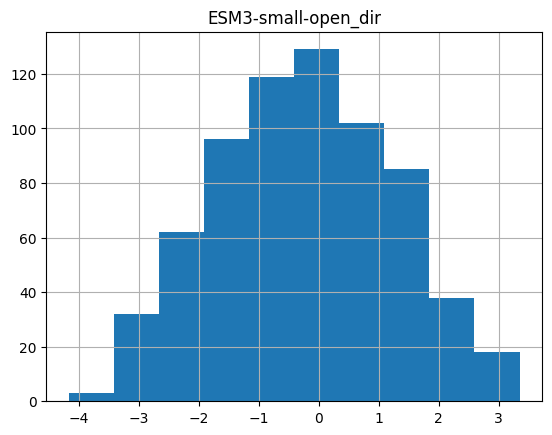

In [35]:
pd.concat([df_sym_comb[['ESM3-small-open_dir']] , df_sym_comb[['ESM3-small-open_inv']].rename({'ESM3-small-open_inv': 'ESM3-small-open_dir'}, axis=1)]).hist()

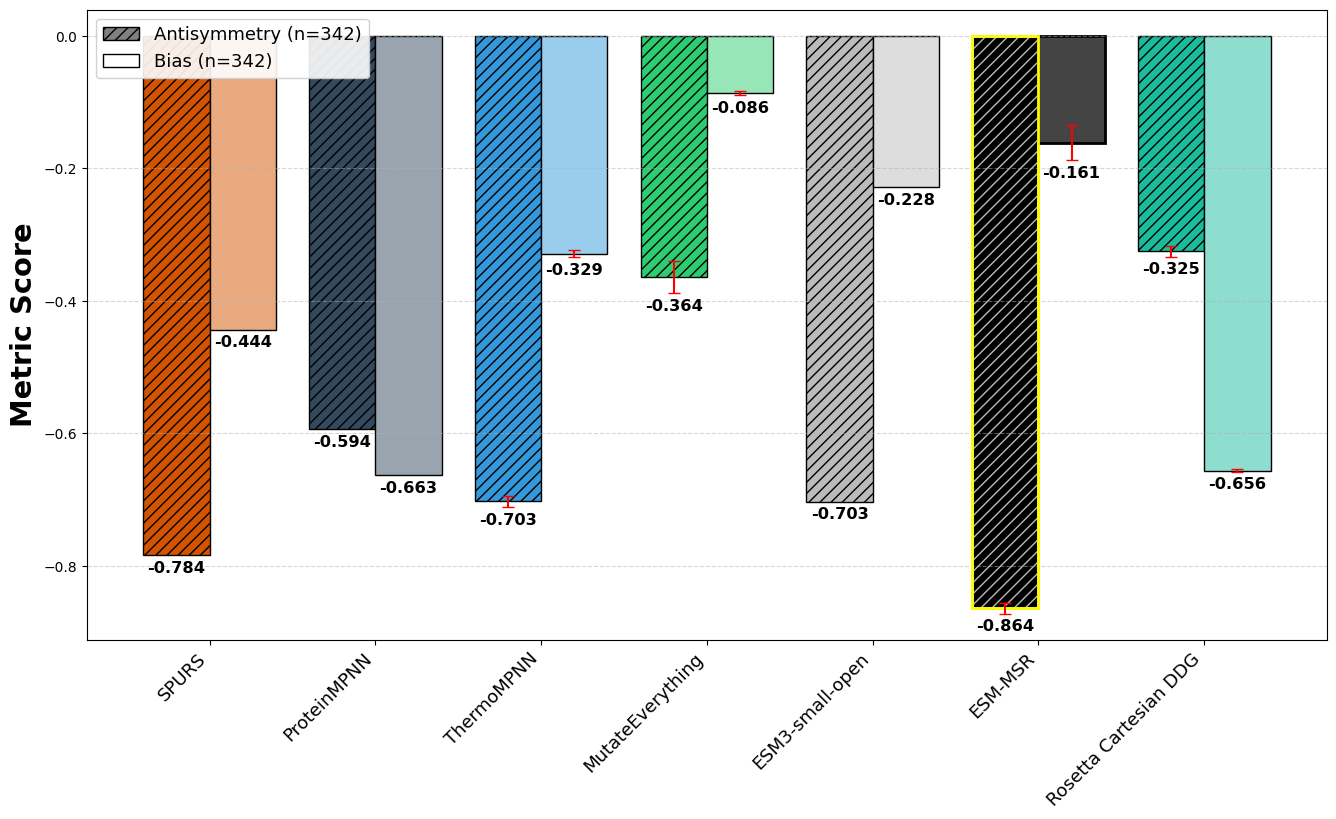

In [36]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)

model_list = ['SPURS', 'ProteinMPNN', 'ThermoMPNN', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM-MSR_direct', 'Rosetta Cartesian DDG'] # 'ESM3-small', 'ESM3-medium', 'ESM3-large',

# 1. Generate the series
s_anti, s_bias = calculate_antisymmetry_and_bias_series(df_sym_comb, model_list)

# 2. Plot using the "Two Series" mode
fig, ax = analysis_utils_msr.create_metric_comparison_chart_epistatic(
    series=s_anti,
    series2=s_bias,
    model_groups=model_list,
    title="",
    y_label="Metric Score",
    series_names=("Antisymmetry", "Bias"),
    highlighted_model='ESM-MSR',
    fontsize_multiplier=1.3,
    figsize=(16,10),
    show_significance=False,
    legend_loc='upper left',
    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", '#1abc9c'],
    is_grouped=False
)

In [37]:
"""
dfs = pd.read_csv('/home/sareeves/software/esm-msr/inference_scripts/predictions/feb19_tsuboyama-validation/zero_shot/esm3-small-2024-08_masked.csv')
dfm = pd.read_csv('/home/sareeves/software/esm-msr/inference_scripts/predictions/feb19_tsuboyama-validation/zero_shot/esm3-medium-2024-08_masked.csv')
dfl = pd.read_csv('/home/sareeves/software/esm-msr/inference_scripts/predictions/feb19_tsuboyama-validation/zero_shot/esm3-large-2024-03_masked.csv')

df_ent = pd.DataFrame()
df_ent['ESM3-small'] = dfs.groupby(['code', 'pos1']).first()['esm3_logits_entropy'].to_numpy()
df_ent['ESM3-medium'] = dfm.groupby(['code', 'pos1']).first()['esm3_logits_entropy'].to_numpy()
df_ent['ESM3-large'] = dfl.groupby(['code', 'pos1']).first()['esm3_logits_entropy'].to_numpy()

import seaborn as sns
from matplotlib import pyplot as plt

my_palette = {
    'ESM3-small': '#e74c3c', 
    'ESM3-medium': '#9b59b6',
    'ESM3-large': '#f39c12',
}

plt.figure(figsize=(12, 8))
sns.violinplot(data=df_ent, palette=my_palette)
plt.ylabel('Per-position logit entropy')
"""

"\ndfs = pd.read_csv('/home/sareeves/software/esm-msr/inference_scripts/predictions/feb19_tsuboyama-validation/zero_shot/esm3-small-2024-08_masked.csv')\ndfm = pd.read_csv('/home/sareeves/software/esm-msr/inference_scripts/predictions/feb19_tsuboyama-validation/zero_shot/esm3-medium-2024-08_masked.csv')\ndfl = pd.read_csv('/home/sareeves/software/esm-msr/inference_scripts/predictions/feb19_tsuboyama-validation/zero_shot/esm3-large-2024-03_masked.csv')\n\ndf_ent = pd.DataFrame()\ndf_ent['ESM3-small'] = dfs.groupby(['code', 'pos1']).first()['esm3_logits_entropy'].to_numpy()\ndf_ent['ESM3-medium'] = dfm.groupby(['code', 'pos1']).first()['esm3_logits_entropy'].to_numpy()\ndf_ent['ESM3-large'] = dfl.groupby(['code', 'pos1']).first()['esm3_logits_entropy'].to_numpy()\n\nimport seaborn as sns\nfrom matplotlib import pyplot as plt\n\nmy_palette = {\n    'ESM3-small': '#e74c3c', \n    'ESM3-medium': '#9b59b6',\n    'ESM3-large': '#f39c12',\n}\n\nplt.figure(figsize=(12, 8))\nsns.violinplot(data=

In [38]:
import importlib
importlib.reload(analysis_utils_msr)
from analysis_utils_msr import calculate_epistasis

df_wu = results['GB1_Wu_2016_binding_domain']
df_wu['id'] = df_wu.index
df_wu['HD'] = df_wu['id'].apply(lambda x: len(x.split(':')))
#df_wu['ddG_pred'] = df_wu['MutateEverything_1']
df_wu['ddG_ML'] = df_wu['ground_truth']

df_wu['code'] = df_wu['id'].apply(lambda x: x.split('_')[0])
df_wu['mut_type'] = df_wu['id'].apply(lambda x: x.split('_')[1])

df_wu = calculate_epistasis(df_wu, val_col=None)
df_wu = df_wu.rename(columns={'ddG_ML_dddG': 'dddG_ML'})
df_wu = df_wu[[c for c in df_wu.columns if not '_additive' in c]]

df_wu

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ThermoMPNN-D_1,ThermoMPNN-D_2,ThermoMPNN-D_3,MutateEverything_1,...,ESM-MSR_alpha20_3_dddG,ESM3-small_dddG,ESM3-medium_dddG,ESM3-large_dddG,ddG_ML_esm_dddG,ddG_ML_me_dddG,ddG_ML_thermo_dddG,ground_truth_dddG,HD_dddG,dddG_ML
uid,,,,,,,,,,,,,,,,,,,,,
GB1_V39E,-1.736338,-1.912331,-3.933005,-0.300141,-0.457132,-0.387534,-0.300141,-0.457132,-0.387534,-3.187229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GB1_V39F,-0.382329,-0.467662,-3.864196,0.084188,0.006625,0.163651,0.084188,0.006625,0.163651,-0.205711,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GB1_V39G,-1.883256,-1.844993,-4.015341,-0.803180,-0.821204,-0.706080,-0.803180,-0.821204,-0.706080,-3.414429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GB1_V39H,-1.381145,-1.384008,-4.346407,0.117673,-0.094036,0.129060,0.117673,-0.094036,0.129060,-1.569858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GB1_V39I,0.087973,-0.518488,0.155686,-0.061461,-0.116024,-0.039102,-0.061461,-0.116024,-0.039102,0.503749,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB1_V39Y:D40Y:G41Y:V54R,-3.426708,-2.961562,-15.838128,NaN,NaN,NaN,NaN,NaN,NaN,-6.183873,...,0.199989,16.919434,22.644531,34.429688,-3.982015,3.982015,NaN,-3.982015,0.0,-3.982015
GB1_V39Y:D40Y:G41Y:V54S,-3.497194,-3.075124,-15.397974,NaN,NaN,NaN,NaN,NaN,NaN,-5.692039,...,0.205471,15.622559,20.597656,34.492188,-4.468537,4.468537,NaN,-4.468537,0.0,-4.468537
GB1_V39Y:D40Y:G41Y:V54T,-3.073617,-2.943167,-15.891892,NaN,NaN,NaN,NaN,NaN,NaN,-4.790289,...,0.208150,13.442871,18.878906,28.179688,-4.571187,4.571187,NaN,-4.571187,0.0,-4.571187


In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_replicate_performance_subplots(data_dict, colors=('#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400', '#34495e'), markers=('s', 'D', 'p', '^', 'v', '<', '>', 'h', 'H', 'o', '*', '+', 'x')):
    """
    Plots mean Spearman correlations and standard deviations for total and epistatic 
    ddG predictions across dataframes in side-by-side subplots.
    """
    
    # Extract baseline counts from the first dataframe
    if not data_dict:
        print("Warning: data_dict is empty.")
        return None
        
    first_df = next(iter(data_dict.values()))
    counts = first_df.groupby('HD').size().rename('Count').reset_index()
    all_hds = sorted(counts['HD'].unique())
    
    # Create 1x2 subplot layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)
    
    # Setup twin axes for the log-scaled counts
    ax1_count = ax1.twinx()
    ax2_count = ax2.twinx()
    
    for ax_c in [ax1_count, ax2_count]:
        ax_c.bar(counts['HD'], counts['Count'], alpha=0.15, color='gray')
        ax_c.set_yscale('log')
        ax_c.tick_params(axis='y', labelcolor='gray')
        if ax_c == ax1_count:
            ax_c.set_yticks([]) 
            
    ax2_count.set_ylabel('Sample Count (N) [Log Scale]', color='gray')
    
    for idx, (prefix, df) in enumerate(data_dict.items()):
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        
        # Dynamically find the replicate columns
        ddg_cols = [c for c in df.columns if c.startswith(prefix) and 'dddG' not in c]
        dddg_cols = [c for c in df.columns if c.startswith(prefix) and 'dddG' in c]

        if not ddg_cols and not dddg_cols:
            print(f"Warning: No columns found for prefix '{prefix}'")
            continue
            
        means_ddg, stds_ddg = [], []
        means_dddg, stds_dddg = [], []
        
        for hd in all_hds:
            hd_mask = df['HD'] == hd
            subset = df[hd_mask]
            
            # Calculate correlation for each replicate independently
            corr_ddg = [subset[col].corr(subset['ddG_ML'], method='spearman') for col in ddg_cols]
            corr_dddg = [subset[col].corr(subset['dddG_ML'], method='spearman') for col in dddg_cols]
            
            means_ddg.append(np.nanmean(corr_ddg) if corr_ddg else 0)
            stds_ddg.append(np.nanstd(corr_ddg, ddof=1) if len(corr_ddg) > 1 else 0)
            
            means_dddg.append(np.nanmean(corr_dddg) if corr_dddg else 0)
            stds_dddg.append(np.nanstd(corr_dddg, ddof=1) if len(corr_dddg) > 1 else 0)
            
        # Plot Total ddG on Ax1
        ax1.errorbar(all_hds, means_ddg, yerr=stds_ddg, fmt=f'-{marker}', color=color, 
                     linewidth=2, capsize=4, label=f'{prefix}')
        
        # Plot Epistatic dddG on Ax2
        ax2.errorbar(all_hds, means_dddg, yerr=stds_dddg, fmt=f'-{marker}', color=color, 
                     linewidth=2, capsize=4, label=f'{prefix}')
        
    for ax in [ax1, ax2]:
        ax.set_xlabel('Hamming Distance (HD)')
        ax.set_ylim(0, 1) 
        ax.set_xticks(all_hds)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
        
    ax1.set_ylabel('Mean Spearman Correlation (ρ) ± SD')
    ax1.set_title('Fitness-Prediction Correlation')
    ax2.set_title('Epistasis-Predicted Epistasis Correlation')
    
    plt.tight_layout()
    plt.show()
    return fig, (ax1, ax2)

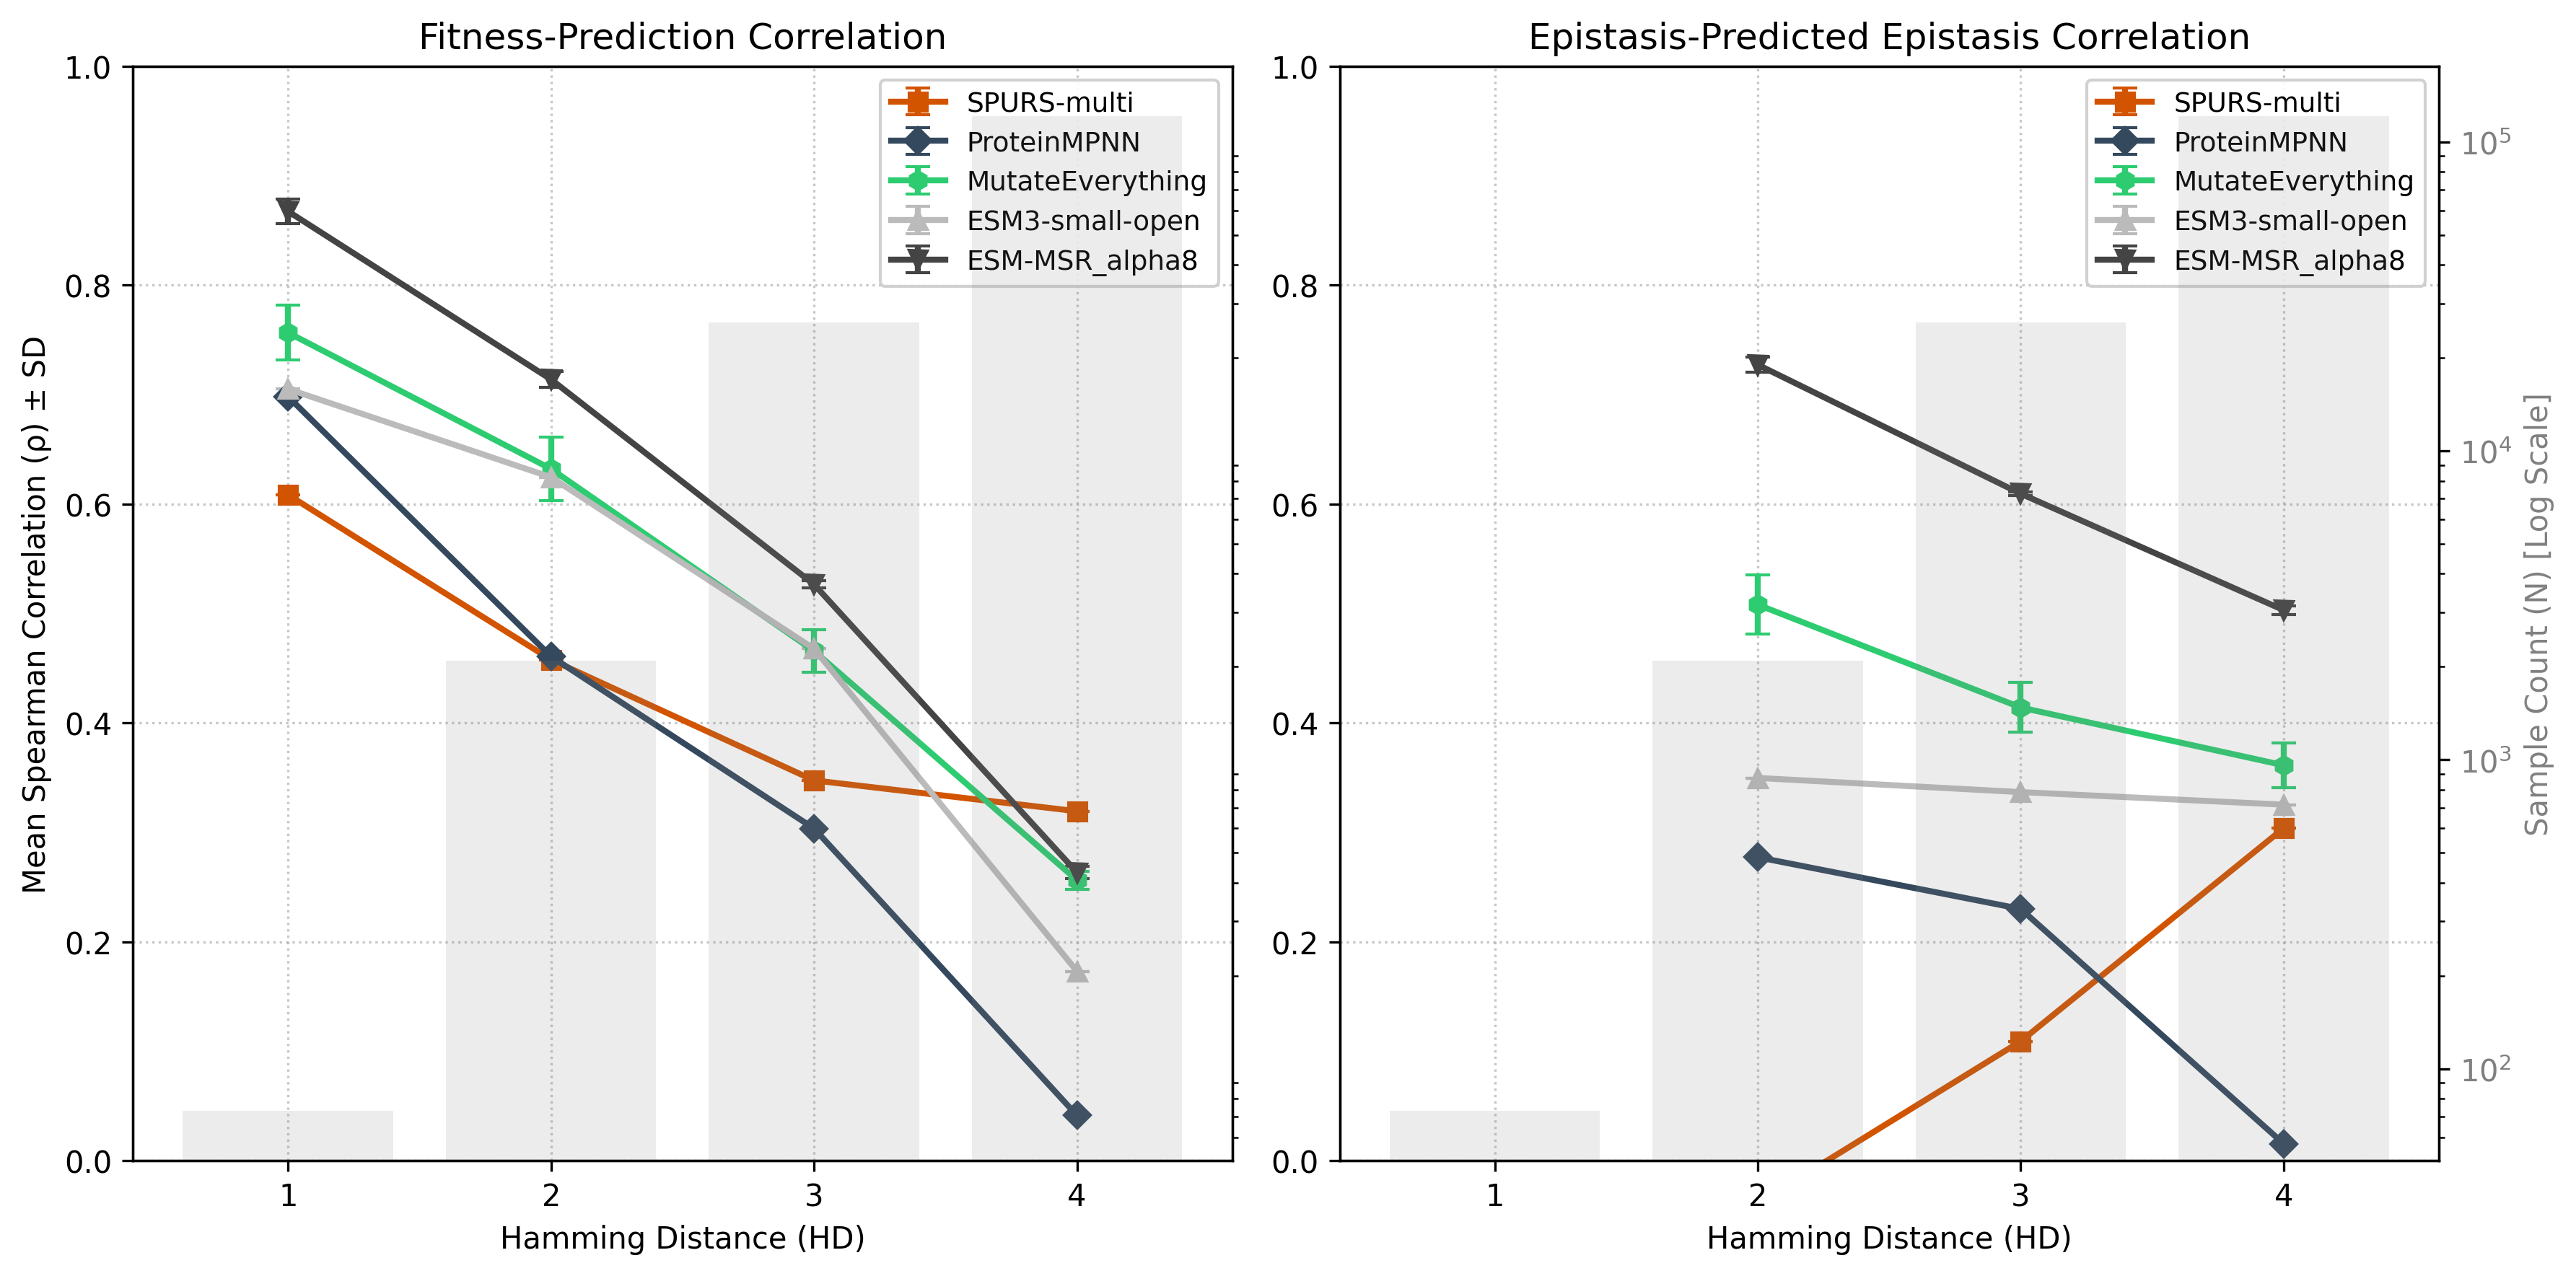

(<Figure size 3600x1800 with 4 Axes>,
 (<Axes: title={'center': 'Fitness-Prediction Correlation'}, xlabel='Hamming Distance (HD)', ylabel='Mean Spearman Correlation (ρ) ± SD'>,
  <Axes: title={'center': 'Epistasis-Predicted Epistasis Correlation'}, xlabel='Hamming Distance (HD)'>))

In [40]:
data_dict = {'SPURS-multi': df_wu, 'ProteinMPNN': df_wu, 'MutateEverything': df_wu, 'ESM3-small-open': df_wu, 'ESM-MSR_alpha8': df_wu} #'ESM-MSR': df_wu, 'ESM-MSR_alpha4': df_wu,
plot_replicate_performance_subplots(data_dict, colors=('#d35400', '#34495e',  '#2ecc71', "#bbbbbb", "#444444",  '#f39c12', '#9b59b6',  '#1abc9c', '#3498db',), markers=('s', 'D', 'h', '^', 'v', '<', '>', 'h', 'H', 'o', '*', '+', 'x'))